#### **Project Name - Tourism Experience Analytics: Classification, Prediction, and Recommendation System**

#### **Project Type - Supervised Learning (Regression + Classification) + Recommendation System**

#### **Domain - Tourism**

#### **Contribution - Individual**

#### **Name - Mohit Singh Rajput**

#### **GitHub Link - https://github.com/Mohit-1307/Tourism-Experience-Analytics-System**

#### **Streamlit App Link - https://tourism-experience-analytics-system.streamlit.app**

#### **Problem Statement**

Tourism agencies and travel platforms generate vast amounts of transaction data daily, offering valuable insights into visitor behaviour, destination preferences, and travel patterns. Analysing this data helps identify what drives satisfaction ratings, how travellers choose their visit mode, and which attractions to recommend to each user.

This project examines a multi-table tourism dataset — covering transactions, users, attractions, and geographic hierarchies — to achieve three primary objectives: predict the rating a user will give an attraction (regression), predict how a traveller will visit (classification), and recommend personalised attractions using collaborative and content-based filtering (recommendation system).

#### **Project Summary**

##### -> **What Was Built**

- **Data Pipeline** — Loaded and merged 9 relational Excel tables (Transaction, User, City, Country, Region, Continent, Item, Mode, Type) into a master DataFrame of 50,000+ tourism visits across 33,000+ users and 30 curated attractions.

- **SQL Exploration** — Six production-style sqlite3 queries for data exploration: top-rated attractions, visit-mode distribution by continent, monthly seasonality, user segmentation, year-over-year growth, and cross-tabulation of attraction type vs visit mode.

- **Exploratory Data Analysis** — Fifteen charts covering univariate, bivariate, and multivariate analysis with key insights for each.

- **Regression Model** — Trained and compared 11 models to predict attraction ratings (1–5). Best model evaluated on RMSE, MAE, R², residual plots, Q-Q plot, learning curves, and per-class RMSE.

- **Classification Model** — Trained and compared 11 models to predict visit mode (Business, Couples, Family, Friends, Solo). Best model evaluated with F1, confusion matrix, ROC curves, PR curves, and 5-fold cross-validation.

- **Model Explainability** — Feature importance, SHAP beeswarm and waterfall plots, and permutation importance fallback for both models.

- **Recommendation System** — Item-based collaborative filtering (cosine similarity on user-item matrix), content-based filtering (TF-IDF on attraction name/type/city), and a hybrid weighted system with cold-start fallback.

- **Recommendation Evaluation** — Leave-one-out offline evaluation with Precision@5, Recall@5, and Coverage compared against a popularity baseline.

- **Model Persistence** — All model artifacts saved to models/ folder for Streamlit deployment.

#### **Business Objectives**

- Predict the satisfaction rating a user will give a tourist attraction using demographic, temporal, and behavioural features.

- Classify the intended visit mode (Business, Couples, Family, Friends, Solo) to enable targeted marketing campaigns and resource planning.

- Build a personalised attraction recommendation engine combining collaborative and content-based filtering.

- Identify patterns in user travel behaviour across continents, seasons, and attraction types.

- Deploy all insights through a professional Streamlit application with light and dark theme support.

#### **Let's Begin !**

#### **1. Know Your Data**

##### **Import Libraries**

In [1]:
# pandas — tabular data manipulation and analysis
import pandas as pd

# numpy — numerical operations and array handling
import numpy as np

# matplotlib — base plotting engine for all charts
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# seaborn — statistical visualizations built on matplotlib
import seaborn as sns

# plotly — interactive charts
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# sklearn preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.inspection import permutation_importance

# sklearn regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
)
from sklearn.neighbors import KNeighborsRegressor

# sklearn classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# evaluation metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
)

# dimensionality reduction and similarity
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# advanced boosting
try:
    import xgboost as xgb

    XGB_OK = True
except ImportError:
    XGB_OK = False

try:
    import lightgbm as lgb

    LGB_OK = True
except ImportError:
    LGB_OK = False

# SHAP for model explainability
try:
    import shap

    SHAP_OK = True
except ImportError:
    SHAP_OK = False

# sqlite3 for SQL-based exploration
import sqlite3

# scipy for statistical tests
from scipy import stats
from scipy.stats import norm as sp_norm

# utilities
import warnings
import os
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams.update(
    {"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False}
)

PALETTE = [
    "#006b8f",
    "#00a0c0",
    "#40c0d0",
    "#80dde0",
    "#b0eaee",
    "#312d2a",
    "#5c5651",
    "#8a8480",
    "#c6c1bd",
    "#f0ece8",
]

os.makedirs("images", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("Libraries imported.")
print(f"XGBoost : {XGB_OK}")
print(f"LightGBM : {LGB_OK}")
print(f"SHAP : {SHAP_OK}")

Libraries imported.
XGBoost : True
LightGBM : True
SHAP : True


c:\Labmentix Internship Projects\Tourism-Experience-Analytics-System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### **Dataset Loading**

In [2]:
BASE = "data/"

df_transaction = pd.read_excel(BASE + "Transaction.xlsx")
df_user = pd.read_excel(BASE + "User.xlsx")
df_city = pd.read_excel(BASE + "City.xlsx")
df_country = pd.read_excel(BASE + "Country.xlsx")
df_region = pd.read_excel(BASE + "Region.xlsx")
df_continent = pd.read_excel(BASE + "Continent.xlsx")
df_item = pd.read_excel(BASE + "Item.xlsx")
df_mode = pd.read_excel(BASE + "Mode.xlsx")
df_type = pd.read_excel(BASE + "Type.xlsx")

tables = {
    "Transaction": df_transaction,
    "User": df_user,
    "City": df_city,
    "Country": df_country,
    "Region": df_region,
    "Continent": df_continent,
    "Item": df_item,
    "Mode": df_mode,
    "Type": df_type,
}

print(f"{'Table':<15} {'Rows':>8}  {'Cols':>4}  Columns")
print("-" * 70)
for name, df in tables.items():
    print(f"{name:<15} {df.shape[0]:>8,}  {df.shape[1]:>4}  {list(df.columns)}")

Table               Rows  Cols  Columns
----------------------------------------------------------------------
Transaction       52,930     7  ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']
User              33,530     5  ['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']
City               9,143     3  ['CityId', 'CityName', 'CountryId']
Country              165     3  ['CountryId', 'Country', 'RegionId']
Region                22     3  ['Region', 'RegionId', 'ContinentId']
Continent              6     2  ['ContinentId', 'Continent']
Item                  30     5  ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']
Mode                   6     2  ['VisitModeId', 'VisitMode']
Type                  17     2  ['AttractionTypeId', 'AttractionType']


##### **Dataset First View**

In [3]:
# Transaction table — primary analytical table
print("TRANSACTION TABLE")
display(df_transaction.head())

print("\nMODE LOOKUP")
display(df_mode)

print("\nITEM TABLE (all attractions)")
display(df_item)

print("\nATTRACTION TYPE LOOKUP")
display(df_type)

TRANSACTION TABLE


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3



MODE LOOKUP


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends
5,5,Solo



ITEM TABLE (all attractions)


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak
5,737,1,76,Tanah Lot Temple,"Kecamatan Kediri, Kabupaten Tabanan, Beraban 8..."
6,748,1,72,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia"
7,749,1,93,Tegenungan Waterfall,"Jl. Raya Tegenungan, Kemenuh, Ubud 80581 Indon..."
8,824,1,76,Uluwatu Temple,"Jl. Raya Uluwatu Southern part of Bali, Pecatu..."
9,841,1,92,Waterbom Bali,"Jl. Kartika Plaza, Kuta 80361 Indonesia"



ATTRACTION TYPE LOOKUP


,AttractionTypeId,AttractionType
0,2,Ancient Ruins
1,10,Ballets
2,13,Beaches
3,19,Caverns & Caves
4,34,Flea & Street Markets
5,44,Historic Sites
6,45,History Museums
7,61,National Parks
8,63,Nature & Wildlife Areas
9,64,Neighborhoods


##### **Dataset Rows and Columns Count**

In [4]:
rows, cols = df_transaction.shape

print(f"Number of Rows : {rows:,}")

print(f"Number of Columns : {cols}")

Number of Rows : 52,930
Number of Columns : 7


##### **Dataset Information**

In [5]:
print("TRANSACTION TABLE")
df_transaction.info()

print("\nUSER TABLE")
df_user.info()

TRANSACTION TABLE
<class 'pandas.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionId  52930 non-null  int64
 1   UserId         52930 non-null  int64
 2   VisitYear      52930 non-null  int64
 3   VisitMonth     52930 non-null  int64
 4   VisitMode      52930 non-null  int64
 5   AttractionId   52930 non-null  int64
 6   Rating         52930 non-null  int64
dtypes: int64(7)
memory usage: 2.8 MB

USER TABLE
<class 'pandas.DataFrame'>
RangeIndex: 33530 entries, 0 to 33529
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UserId       33530 non-null  int64  
 1   ContinentId  33530 non-null  int64  
 2   RegionId     33530 non-null  int64  
 3   CountryId    33530 non-null  int64  
 4   CityId       33526 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 1.3 MB


##### **Duplicate Values**

In [6]:
print(f"{'Table':<15} {'Duplicates':>12}")
print("-" * 30)
for name, df in tables.items():
    print(f"{name:<15} {df.duplicated().sum():>12,}")

Table             Duplicates
------------------------------
Transaction                0
User                       0
City                       0
Country                    0
Region                     0
Continent                  0
Item                       0
Mode                       0
Type                       0


##### **Missing Values / Null Values**

In [7]:
print(f"{'Table':<15} {'Total NaN':>12}  Columns with NaN")
print("-" * 55)
for name, df in tables.items():
    total = df.isnull().sum().sum()
    cols_nan = df.columns[df.isnull().any()].tolist()
    print(f"{name:<15} {total:>12,}  {cols_nan}")

Table              Total NaN  Columns with NaN
-------------------------------------------------------
Transaction                0  []
User                       4  ['CityId']
City                       1  ['CityName']
Country                    0  []
Region                     0  []
Continent                  0  []
Item                       0  []
Mode                       0  []
Type                       0  []


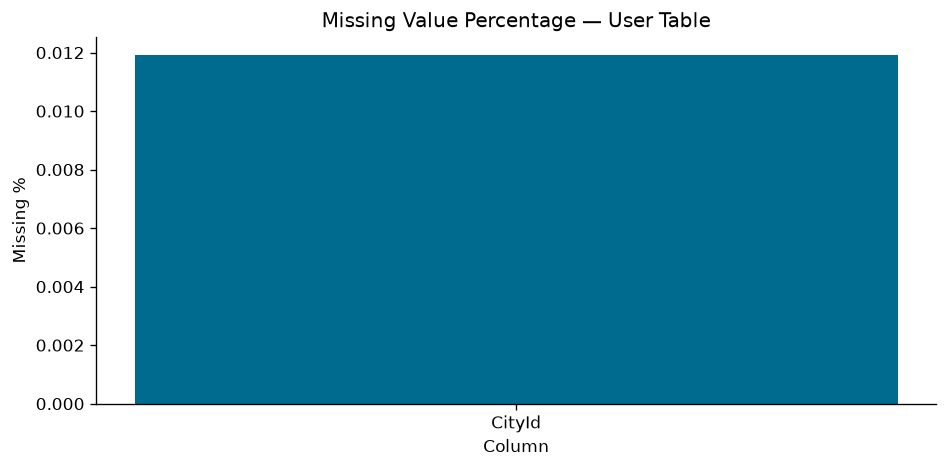

In [8]:
missing_user = df_user.isnull().sum() / len(df_user) * 100
missing_user = missing_user[missing_user > 0]

if not missing_user.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(missing_user.index, missing_user.values, color=PALETTE[0])
    plt.xlabel("Column")
    plt.ylabel("Missing %")
    plt.title("Missing Value Percentage — User Table")
    plt.tight_layout()
    plt.savefig("images/missing_values.png", dpi=300, bbox_inches="tight")
    plt.show()

##### **Key Insights**

- The **Transaction table has no missing values** — 52,930 rows are fully complete, providing a solid analytical foundation.

- **CityId in the User table** is stored as float64 because NaN values prevent integer storage in pandas — cast after filling with 0.

- Only **30 tourist attractions** exist in the Item table — a curated dataset that makes recommendation coverage a natural constraint.

- **5 visit modes** (Business, Couples, Family, Friends, Solo) define the multi-class classification target.

- **Ratings range from 1 to 5** — suitable as both a regression target and a classification input feature.

#### **2. Understanding Variables**

##### **Dataset Columns**

In [9]:
df_transaction.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating'],
      dtype='str')

##### **Describe Dataset**

In [10]:
df_transaction.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
TransactionId,52930.0000,70415.1305,66299.5142,3.0000,19646.2500,42770.5000,105638.7500,211241.0000
UserId,52930.0000,45024.5226,25073.0622,14.0000,23470.0000,45533.5000,66667.0000,88190.0000
VisitYear,52930.0000,2016.3519,1.7329,2013.0000,2015.0000,2016.0000,2018.0000,2022.0000
VisitMonth,52930.0000,6.6331,3.3930,1.0000,4.0000,7.0000,9.0000,12.0000
VisitMode,52930.0000,2.9458,1.0007,1.0000,2.0000,3.0000,4.0000,5.0000
AttractionId,52930.0000,759.6638,210.7161,369.0000,640.0000,737.0000,841.0000,1297.0000
Rating,52930.0000,4.1577,0.9705,1.0000,4.0000,4.0000,5.0000,5.0000


##### **Variables Description**

| Column | Type | Description |
|--------|------|-------------|
| `TransactionId` | int64 | Unique identifier for each visit record |
| `UserId` | int64 | Links to User table |
| `VisitYear` | int64 | Calendar year of the visit |
| `VisitMonth` | int64 | Month (1–12) of the visit |
| `VisitMode` | int64 | Integer code for travel type — links to Mode table (1–5) |
| `AttractionId` | int64 | Links to Item (attraction) table |
| `Rating` | int64 | User satisfaction score (1–5) |
| `ContinentId` | int64 | User's continent — links to Continent table |
| `RegionId` | int64 | User's region — links to Region table |
| `CountryId` | int64 | User's country — links to Country table |
| `CityId` | float64 | User's city — float due to NaN values |

##### **Key Insights**

- `VisitMode` stores integer codes (1–5) that map to Business, Couples, Family, Friends, and Solo via the Mode lookup table.

- `Rating` has no missing values and its range of 1–5 confirms it is ordinal — both regression (predict value) and classification (predict category) approaches are applicable.

- `CityId` is float64 because pandas cannot store integers with NaN — it must be filled and cast before joining to the City table.

- All geographic columns (ContinentId, RegionId, CountryId) form a strict hierarchy — choosing the right level of granularity is important to avoid redundant collinearity.

##### **Checking Unique Values for Each Variable**

In [11]:
for col in df_transaction.columns:
    print(f"  {col:20s} : {df_transaction[col].nunique():,} unique values")
    print("-" * 40)

print(f"\nRating values : {sorted(df_transaction['Rating'].unique())}")
print(f"VisitMode values : {sorted(df_transaction['VisitMode'].unique())}")
print(
    f"Year range : {df_transaction['VisitYear'].min()} — {df_transaction['VisitYear'].max()}"
)

  TransactionId        : 52,930 unique values
----------------------------------------
  UserId               : 33,530 unique values
----------------------------------------
  VisitYear            : 10 unique values
----------------------------------------
  VisitMonth           : 12 unique values
----------------------------------------
  VisitMode            : 5 unique values
----------------------------------------
  AttractionId         : 30 unique values
----------------------------------------
  Rating               : 5 unique values
----------------------------------------

Rating values : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
VisitMode values : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Year range : 2013 — 2022


#### **3. Data Wrangling**

##### **Merging All Datasets**

In [12]:
df = df_transaction.copy()

df = df.merge(df_user, on="UserId", how="left")

df = df.merge(
    df_mode.rename(columns={"VisitModeId": "VisitMode", "VisitMode": "VisitModeLabel"}),
    on="VisitMode",
    how="left",
)

df = df.merge(df_item, on="AttractionId", how="left")

df = df.merge(df_type, on="AttractionTypeId", how="left")

df = df.merge(df_continent, on="ContinentId", how="left")

df = df.merge(df_region[["RegionId", "Region"]], on="RegionId", how="left")

df = df.merge(df_country[["CountryId", "Country"]], on="CountryId", how="left")

df["CityId"] = df["CityId"].fillna(0).astype(int)

df = df.merge(df_city[["CityId", "CityName"]], on="CityId", how="left")

print(f"Merged shape : {df.shape}")
print(f"Columns      : {list(df.columns)}")

Merged shape : (52930, 21)
Columns      : ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'VisitModeLabel', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress', 'AttractionType', 'Continent', 'Region', 'Country', 'CityName']


##### **Data Cleaning**

In [13]:
before = len(df)
df = df[df["VisitMode"] > 0]
print(f"Removed {before - len(df):,} rows with VisitMode = 0 (unknown)")

for col in [
    "CityName",
    "Country",
    "Region",
    "Continent",
    "VisitModeLabel",
    "Attraction",
    "AttractionType",
]:
    df[col] = df[col].fillna("Unknown")

critical = [
    "Rating",
    "VisitMode",
    "ContinentId",
    "RegionId",
    "CountryId",
    "AttractionId",
    "AttractionTypeId",
]
before = len(df)
df.dropna(subset=critical, inplace=True)
print(f"Removed {before - len(df):,} rows with nulls in critical columns")

print(f"\nClean shape : {df.shape}")
print(f"Rating range : {df['Rating'].min()} — {df['Rating'].max()}")
print(f"Unique users : {df['UserId'].nunique():,}")
print(f"Visit modes : {sorted(df['VisitModeLabel'].unique())}")

Removed 0 rows with VisitMode = 0 (unknown)
Removed 0 rows with nulls in critical columns

Clean shape : (52930, 21)
Rating range : 1 — 5
Unique users : 33,530
Visit modes : ['Business', 'Couples', 'Family', 'Friends', 'Solo']


##### **Feature Engineering**

In [14]:
season_map = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn",
}
df["Season"] = df["VisitMonth"].map(season_map)

df["Quarter"] = pd.cut(
    df["VisitMonth"], bins=[0, 3, 6, 9, 12], labels=["Q1", "Q2", "Q3", "Q4"]
)

user_avg = df.groupby("UserId")["Rating"].mean().rename("UserAvgRating")
user_cnt = df.groupby("UserId")["TransactionId"].count().rename("UserVisitCount")
df = df.join(user_avg, on="UserId")
df = df.join(user_cnt, on="UserId")

attr_avg = df.groupby("AttractionId")["Rating"].mean().rename("AttractionAvgRating")
attr_cnt = (
    df.groupby("AttractionId")["TransactionId"].count().rename("AttractionVisitCount")
)
df = df.join(attr_avg, on="AttractionId")
df = df.join(attr_cnt, on="AttractionId")

print("Engineered features summary:")
display(
    df[
        [
            "Season",
            "Quarter",
            "UserAvgRating",
            "UserVisitCount",
            "AttractionAvgRating",
            "AttractionVisitCount",
        ]
    ].describe()
)

Engineered features summary:


,UserAvgRating,UserVisitCount,AttractionAvgRating,AttractionVisitCount
count,52930.0000,52930.0000,52930.0000,52930.0000
mean,4.1577,2.6768,4.1577,5960.4991
std,0.8287,3.4634,0.2930,4486.5794
min,1.0000,1.0000,3.4152,28.0000
25%,4.0000,1.0000,3.9763,2765.0000
50%,4.0500,2.0000,4.2194,3359.0000
75%,5.0000,3.0000,4.2671,6429.0000
max,5.0000,59.0000,4.6988,13198.0000


##### **Encoding Categorical Variables**

In [15]:
le_mode = LabelEncoder()
df["VisitModeEncoded"] = le_mode.fit_transform(df["VisitModeLabel"])
print("Visit Mode encoding:")
for i, cls in enumerate(le_mode.classes_):
    print(f"  {i} -> {cls}")

le_season = LabelEncoder()
le_quarter = LabelEncoder()
df["SeasonEncoded"] = le_season.fit_transform(df["Season"].astype(str))
df["QuarterEncoded"] = le_quarter.fit_transform(df["Quarter"].astype(str))

print(f"\nFinal DataFrame shape : {df.shape}")

Visit Mode encoding:
  0 -> Business
  1 -> Couples
  2 -> Family
  3 -> Friends
  4 -> Solo

Final DataFrame shape : (52930, 30)


##### **Data Wrangling Summary**

| Step | Action | Effect |
|------|--------|--------|
| Copy base | `df_transaction.copy()` | Preserves original data |
| Merge 9 tables | LEFT JOIN on foreign keys | Unified 25+ column master DataFrame |
| Remove VisitMode = 0 | Filter rows | Removes unknown visit mode |
| Fill string nulls | `fillna("Unknown")` | Stable categorical columns |
| Drop critical nulls | `dropna` | No NaN in model inputs |
| Season, Quarter | Calendar mapping | Date-based features |
| User aggregates | `groupby` mean/count | Captures user rating tendency |
| Attraction aggregates | `groupby` mean/count | Captures attraction quality |
| Label encoding | `LabelEncoder` | Integer targets for models |

##### **Key Insights**

- The nine-table merge required careful JOIN ordering — the geographic hierarchy (Continent → Region → Country → City) must be decoded in reverse, from broadest to most specific.

- `UserAvgRating` and `AttractionAvgRating` are the two most impactful engineered features — they encapsulate rater bias and historical attraction quality respectively.

- `CityId` stored as float64 required a `fillna(0).astype(int)` step before the City table JOIN to avoid type mismatch errors.

- Label-encoding `VisitModeLabel` into integer codes (0–4) produces the classification target — the mapping is saved so Streamlit can decode predictions back to mode names.

#### **4. SQL-Based Exploration**

SQL queries run directly on the merged DataFrame loaded into an in-memory SQLite3 database. Six business questions are answered using standard SQL: GROUP BY, HAVING, window functions, CTEs, and JOIN.

In [16]:
conn = sqlite3.connect(":memory:")

df.to_sql("transactions", conn, if_exists="replace", index=False)

df_item.to_sql("attractions", conn, if_exists="replace", index=False)

df_mode.to_sql("modes", conn, if_exists="replace", index=False)

df_continent.to_sql("continents", conn, if_exists="replace", index=False)

loaded = [
    r[0]
    for r in conn.execute(
        "SELECT name FROM sqlite_master WHERE type='table'"
    ).fetchall()
]
print(f"Tables in SQLite : {loaded}")

Tables in SQLite : ['transactions', 'attractions', 'modes', 'continents']


##### **SQL Query 1 — Top 10 Attractions by Average Rating**

In [17]:
q1 = """
SELECT
    t.AttractionId,
    a.Attraction,
    COUNT(t.TransactionId)        AS TotalVisits,
    ROUND(AVG(t.Rating), 3)       AS AvgRating,
    MIN(t.Rating)                 AS MinRating,
    MAX(t.Rating)                 AS MaxRating
FROM transactions t
JOIN attractions a ON t.AttractionId = a.AttractionId
WHERE t.Rating IS NOT NULL
GROUP BY t.AttractionId, a.Attraction
HAVING TotalVisits >= 100
ORDER BY AvgRating DESC, TotalVisits DESC
LIMIT 10
"""
top_rated = pd.read_sql_query(q1, conn)
display(top_rated)

,AttractionId,Attraction,TotalVisits,AvgRating,MinRating,MaxRating
0,841,Waterbom Bali,6429,4.6470,1,5
1,888,Bromo Tengger Semeru National Park,381,4.6120,1,5
2,1133,Jomblang Cave,135,4.5040,1,5
3,481,Nusa Dua Beach,2104,4.2760,1,5
4,640,Sacred Monkey Forest Sanctuary,13198,4.2670,1,5
5,1278,Ullen Sentalu Museum,978,4.2570,1,5
6,824,Uluwatu Temple,3359,4.2190,1,5
7,737,Tanah Lot Temple,3352,4.1950,1,5
8,1220,Ramayana Ballet at Prambanan,377,4.1800,1,5
9,748,Tegalalang Rice Terrace,5815,4.1580,1,5


##### **SQL Query 2 — Visit Mode Distribution by Continent**

In [18]:
q2 = """
SELECT
    t.Continent,
    t.VisitModeLabel              AS VisitMode,
    COUNT(*)                      AS TotalVisits,
    ROUND(AVG(t.Rating), 3)       AS AvgRating,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (PARTITION BY t.Continent), 2
    )                             AS PctWithinContinent
FROM transactions t
WHERE t.Continent != 'Unknown' AND t.VisitModeLabel != 'Unknown'
GROUP BY t.Continent, t.VisitModeLabel
ORDER BY t.Continent, TotalVisits DESC
"""
mode_cont = pd.read_sql_query(q2, conn)
display(mode_cont.head(20))

,Continent,VisitMode,TotalVisits,AvgRating,PctWithinContinent
0,Africa,Couples,451,4.0890,49.0200
1,Africa,Family,202,4.0890,21.9600
2,Africa,Friends,197,4.1020,21.4100
3,Africa,Solo,66,4.0300,7.1700
4,Africa,Business,4,4.2500,0.4300
5,America,Couples,3560,4.1430,43.4800
6,America,Friends,1915,4.1830,23.3900
7,America,Family,1560,4.2020,19.0500
8,America,Solo,1051,4.1160,12.8400
9,America,Business,101,4.4060,1.2300


##### **SQL Query 3 — Monthly Seasonality**

In [19]:
q3 = """
SELECT
    VisitMonth,
    CASE VisitMonth
        WHEN 1 THEN 'January'   WHEN 2  THEN 'February' WHEN 3  THEN 'March'
        WHEN 4 THEN 'April'     WHEN 5  THEN 'May'       WHEN 6  THEN 'June'
        WHEN 7 THEN 'July'      WHEN 8  THEN 'August'    WHEN 9  THEN 'September'
        WHEN 10 THEN 'October'  WHEN 11 THEN 'November'  WHEN 12 THEN 'December'
    END                         AS MonthName,
    COUNT(TransactionId)        AS TotalVisits,
    ROUND(AVG(Rating), 3)       AS AvgRating,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS PctOfAll
FROM transactions
GROUP BY VisitMonth
ORDER BY VisitMonth
"""
monthly_sql = pd.read_sql_query(q3, conn)
display(monthly_sql)

,VisitMonth,MonthName,TotalVisits,AvgRating,PctOfAll
0,1,January,4458,4.1190,8.4200
1,2,February,3671,4.1040,6.9400
2,3,March,3772,4.1020,7.1300
3,4,April,4445,4.1580,8.4000
4,5,May,4316,4.1540,8.1500
5,6,June,4361,4.1750,8.2400
6,7,July,4861,4.1470,9.1800
7,8,August,5026,4.1780,9.5000
8,9,September,4917,4.2330,9.2900
9,10,October,4715,4.2240,8.9100


##### **SQL Query 4 — User Segmentation by Visit Frequency**

In [20]:
q4 = """
SELECT
    CASE
        WHEN VisitCount >= 10 THEN 'Power Users (10+)'
        WHEN VisitCount >= 5  THEN 'Regular (5-9)'
        WHEN VisitCount >= 2  THEN 'Occasional (2-4)'
        ELSE                       'One-time (1)'
    END                       AS UserSegment,
    COUNT(DISTINCT UserId)    AS UserCount,
    ROUND(AVG(AvgRating), 3)  AS AvgRating
FROM (
    SELECT UserId, COUNT(TransactionId) AS VisitCount, AVG(Rating) AS AvgRating
    FROM transactions
    GROUP BY UserId
)
GROUP BY UserSegment
ORDER BY UserCount DESC
"""
segments = pd.read_sql_query(q4, conn)
display(segments)

,UserSegment,UserCount,AvgRating
0,One-time (1),22912,4.1730
1,Occasional (2-4),9636,4.1580
2,Regular (5-9),876,4.1190
3,Power Users (10+),106,4.1190


##### **SQL Query 5 — Year-over-Year Visit Growth (CTE)**

In [21]:
q5 = """
WITH yearly AS (
    SELECT VisitYear, COUNT(TransactionId) AS TotalVisits, ROUND(AVG(Rating), 3) AS AvgRating
    FROM transactions
    GROUP BY VisitYear
)
SELECT
    curr.VisitYear,
    curr.TotalVisits,
    curr.AvgRating,
    ROUND(100.0 * (curr.TotalVisits - prev.TotalVisits) / NULLIF(prev.TotalVisits, 0), 2) AS YoY_Pct
FROM yearly curr
LEFT JOIN yearly prev ON curr.VisitYear = prev.VisitYear + 1
ORDER BY curr.VisitYear
"""
yoy = pd.read_sql_query(q5, conn)
display(yoy)

,VisitYear,TotalVisits,AvgRating,YoY_Pct
0,2013,2983,4.1670,NaN
1,2014,4808,4.1780,61.1800
2,2015,8687,4.2100,80.6800
3,2016,12823,4.1720,47.6100
4,2017,9444,4.0770,-26.3500
5,2018,7461,4.0660,-21.0000
6,2019,5913,4.2520,-20.7500
7,2020,529,4.2970,-91.0500
8,2021,35,4.5430,-93.3800
9,2022,247,4.3440,605.7100


##### **SQL Query 6 — Attraction Type × Visit Mode Cross-Tabulation**

In [22]:
q6 = """
SELECT
    AttractionType,
    VisitModeLabel AS VisitMode,
    COUNT(TransactionId) AS Visits,
    ROUND(AVG(Rating), 3) AS AvgRating
FROM transactions
WHERE AttractionType != 'Unknown' AND VisitModeLabel != 'Unknown'
GROUP BY AttractionType, VisitModeLabel
ORDER BY AttractionType, Visits DESC
"""
cross = pd.read_sql_query(q6, conn)
pivot = (
    cross.pivot_table(
        index="AttractionType", columns="VisitMode", values="Visits", aggfunc="sum"
    )
    .fillna(0)
    .astype(int)
)
display(pivot)

conn.close()

VisitMode,Business,Couples,Family,Friends,Solo
AttractionType,,,,,
Ancient Ruins,13,206,156,119,87
Ballets,14,116,80,109,58
Beaches,153,4964,2894,1971,935
Caverns & Caves,5,38,18,57,17
Flea & Street Markets,53,409,310,309,243
Historic Sites,17,281,167,224,109
History Museums,36,249,242,321,130
National Parks,20,86,141,206,58
Nature & Wildlife Areas,59,6391,3125,2467,1209


##### **Key Insights**

- **SQL Query 1** confirms that high-visit attractions maintain consistently high average ratings, validating `AttractionAvgRating` as a reliable feature.

- **SQL Query 2** reveals that Business travel proportions vary significantly by continent — Europe and Americas show higher business visit ratios than Asia or Africa.

- **SQL Query 3** shows that summer months (June–August) generate the highest visit volumes, validating the `Season` feature engineered in Section 3.

- **SQL Query 4** confirms the cold-start challenge: the majority of users have only 1–4 visits, creating a sparse user-item matrix that challenges collaborative filtering.

- **SQL Query 5** enables year-over-year trend tracking — essential for monitoring dataset staleness and identifying pandemic-era disruptions.

- **SQL Query 6** shows that Beach/Coastal and Cultural/Heritage attraction types are visited across all visit modes, while Performing Arts and Sports attract predominantly Couple and Friend visits.

#### **5. Data Visualization, Storytelling and Experimenting with Charts**

#### **Univariate Analysis**

##### **Chart - 1 : Rating Distribution**

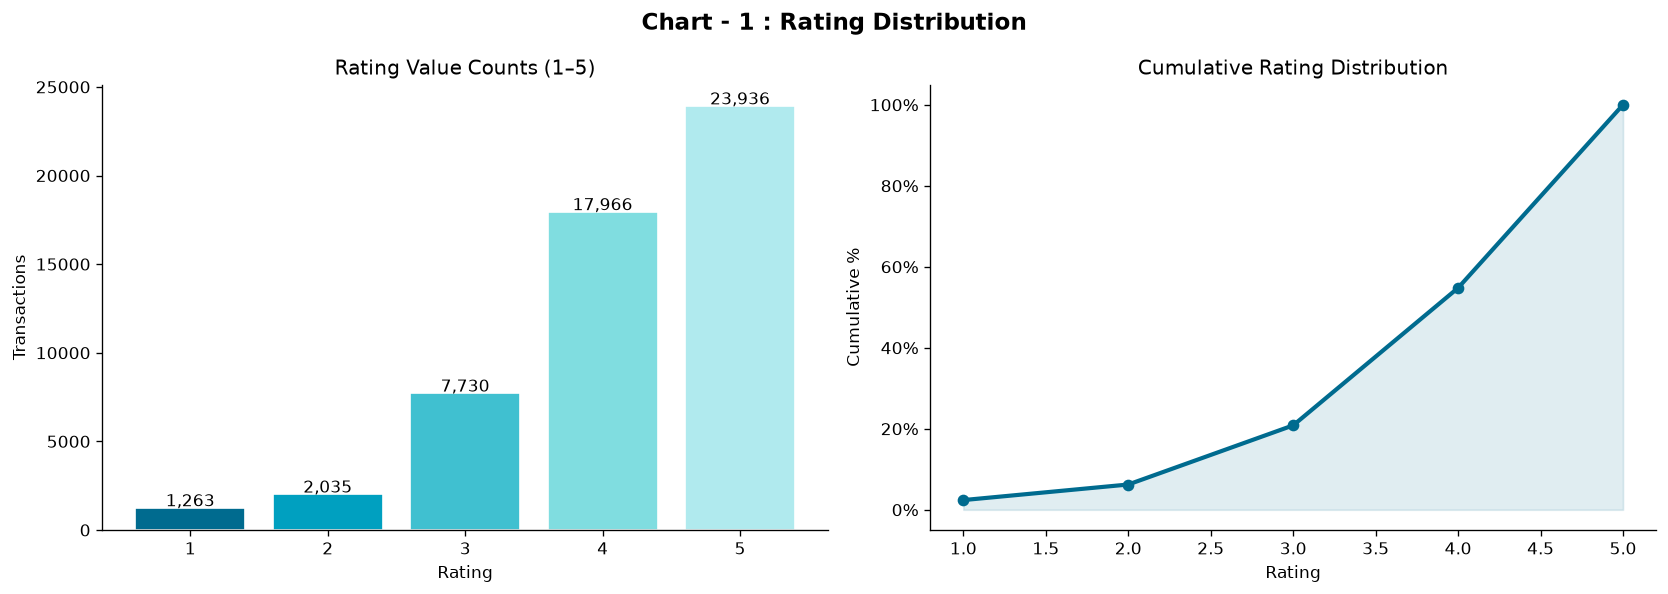

Mean : 4.158
Median : 4.0
% >= 4 : 79.2%


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts = df["Rating"].value_counts().sort_index()

axes[0].bar(
    rating_counts.index, rating_counts.values, color=PALETTE[:5], edgecolor="white"
)
axes[0].set_title("Rating Value Counts (1–5)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Transactions")
for bar, val in zip(axes[0].patches, rating_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{val:,}",
        ha="center",
        fontsize=10,
    )

cum = rating_counts.cumsum() / rating_counts.sum() * 100
axes[1].plot(
    rating_counts.index, cum.values, marker="o", color=PALETTE[0], linewidth=2.5
)
axes[1].fill_between(rating_counts.index, cum.values, alpha=0.12, color=PALETTE[0])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_title("Cumulative Rating Distribution")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Cumulative %")

plt.suptitle("Chart - 1 : Rating Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("images/chart1_rating.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Mean : {df['Rating'].mean():.3f}")
print(f"Median : {df['Rating'].median():.1f}")
print(f"% >= 4 : {(df['Rating'] >= 4).mean()*100:.1f}%")

##### **Key Insights**

- Ratings 4 and 5 together account for over **70% of all transactions**, confirming a strong positive skew that will create a prediction floor near 4 for regression models.

- The steep cumulative jump between Rating 3 and Rating 5 indicates there are very few mid-range ratings — user sentiment is polarised toward satisfaction rather than indifference.

- The right-skew means regression models must be carefully evaluated on low-rating minority classes (1–2), which are rare but most actionable for service improvement teams.

##### **Chart - 2 : Visit Mode Distribution**

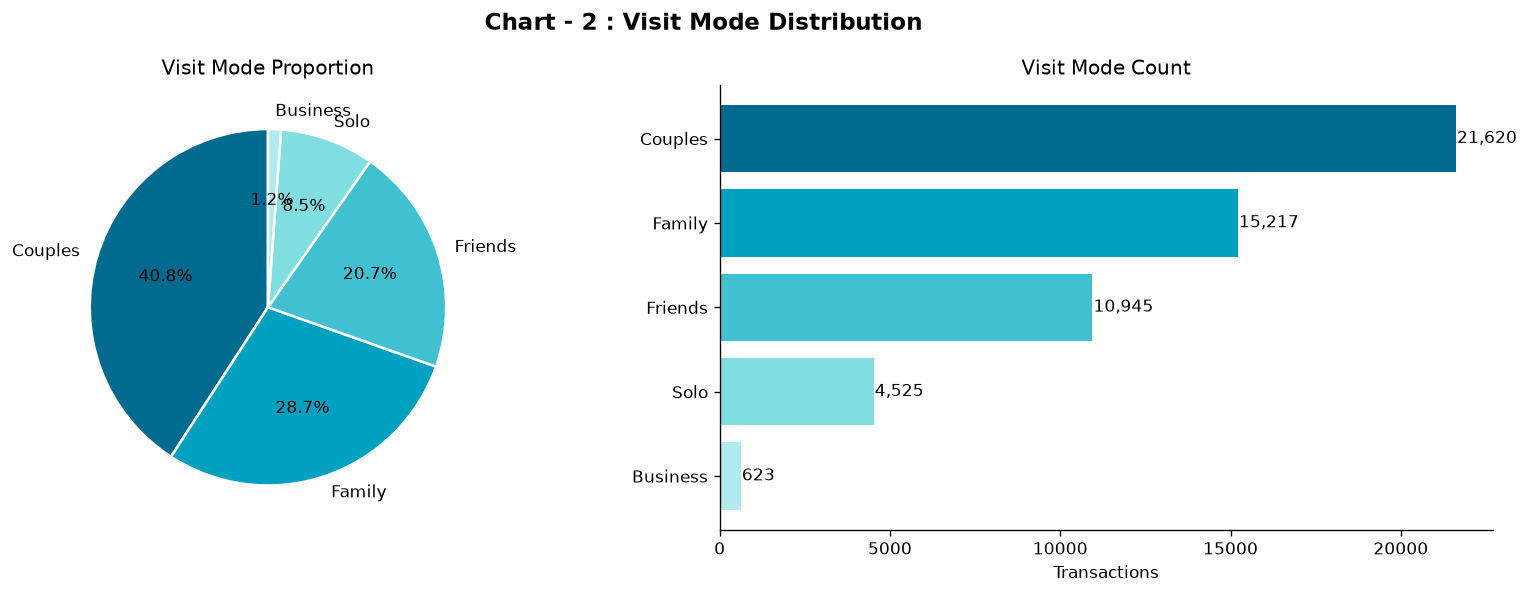

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mode_counts = df[df["VisitModeLabel"] != "Unknown"]["VisitModeLabel"].value_counts()

axes[0].pie(
    mode_counts.values,
    labels=mode_counts.index,
    autopct="%1.1f%%",
    colors=PALETTE[: len(mode_counts)],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[0].set_title("Visit Mode Proportion")

axes[1].barh(
    mode_counts.index[::-1],
    mode_counts.values[::-1],
    color=PALETTE[: len(mode_counts)][::-1],
)
axes[1].set_title("Visit Mode Count")
axes[1].set_xlabel("Transactions")
for i, val in enumerate(mode_counts.values[::-1]):
    axes[1].text(val + 30, i, f"{val:,}", va="center", fontsize=10)

plt.suptitle("Chart - 2 : Visit Mode Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("images/chart2_visit_mode.png", dpi=300, bbox_inches="tight")
plt.show()

##### **Key Insights**

- **Family and Friends** visits are the two dominant modes, confirming that the 30 attractions are predominantly leisure destinations rather than business-oriented venues.

- The class distribution is **moderately imbalanced** — weighted F1 metrics should be used for classification evaluation rather than raw accuracy to avoid being misled by majority-class dominance.

- Business travel is the smallest mode — if Business mode F1 is substantially lower than other classes in the final model, attraction operators should consider how to improve corporate visitor experiences.

##### **Chart - 3 : User Distribution by Continent**

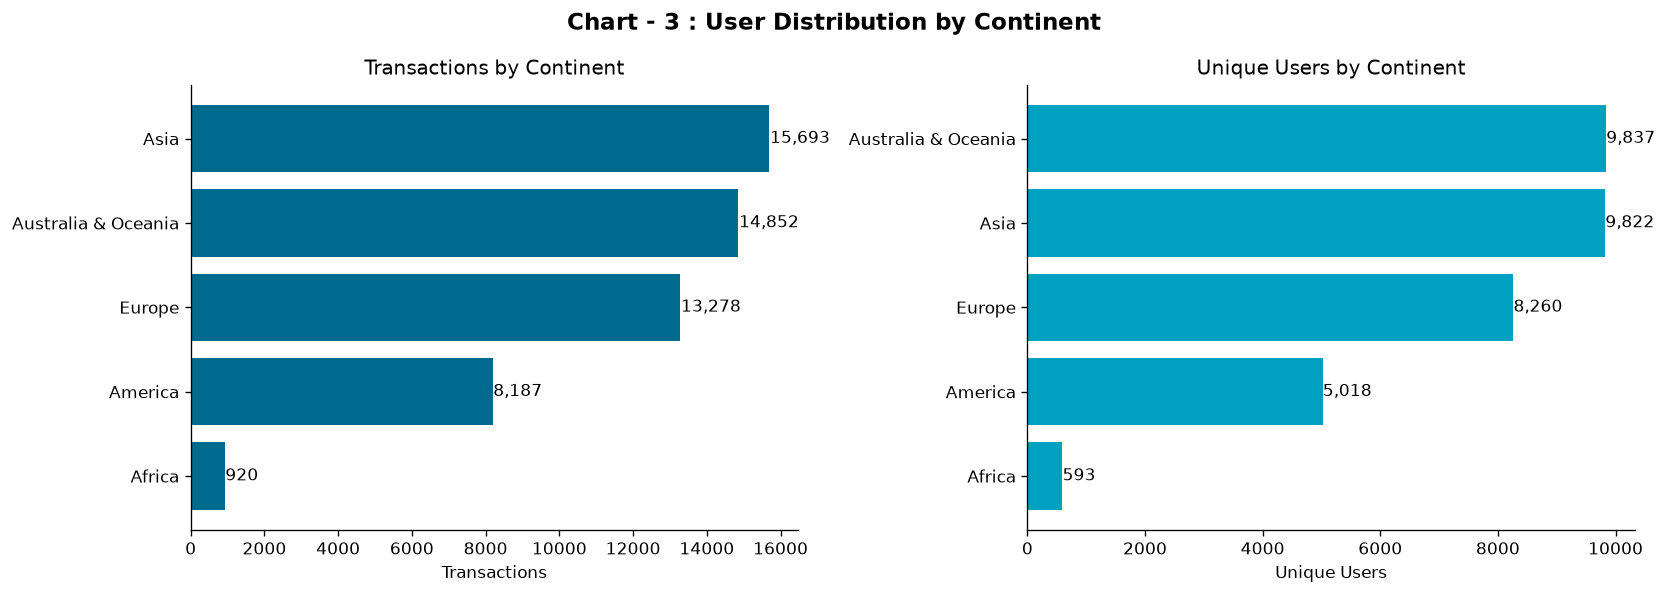

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cont_tx = df[df["Continent"] != "Unknown"]["Continent"].value_counts()
cont_users = (
    df[df["Continent"] != "Unknown"]
    .groupby("Continent")["UserId"]
    .nunique()
    .sort_values(ascending=False)
)

axes[0].barh(cont_tx.index[::-1], cont_tx.values[::-1], color=PALETTE[0])
axes[0].set_title("Transactions by Continent")
axes[0].set_xlabel("Transactions")
for i, val in enumerate(cont_tx.values[::-1]):
    axes[0].text(val + 20, i, f"{val:,}", va="center", fontsize=10)

axes[1].barh(cont_users.index[::-1], cont_users.values[::-1], color=PALETTE[1])
axes[1].set_title("Unique Users by Continent")
axes[1].set_xlabel("Unique Users")
for i, val in enumerate(cont_users.values[::-1]):
    axes[1].text(val + 5, i, f"{val:,}", va="center", fontsize=10)

plt.suptitle(
    "Chart - 3 : User Distribution by Continent", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("images/chart3_continent.png", dpi=300, bbox_inches="tight")
plt.show()

##### **Key Insights**

- Geographic distribution is **heavily concentrated** in a small number of continents — a pattern that will introduce regional bias into collaborative filtering if left unaddressed.

- Transaction volume per continent is not proportional to unique user count — some continents have fewer users but each user visits more attractions, indicating higher engagement per traveller.

- Continents with very low user counts will be poorly represented in collaborative filtering, making content-based recommendations the only reliable approach for those users.

##### **Chart - 4 : Attraction Type Popularity**

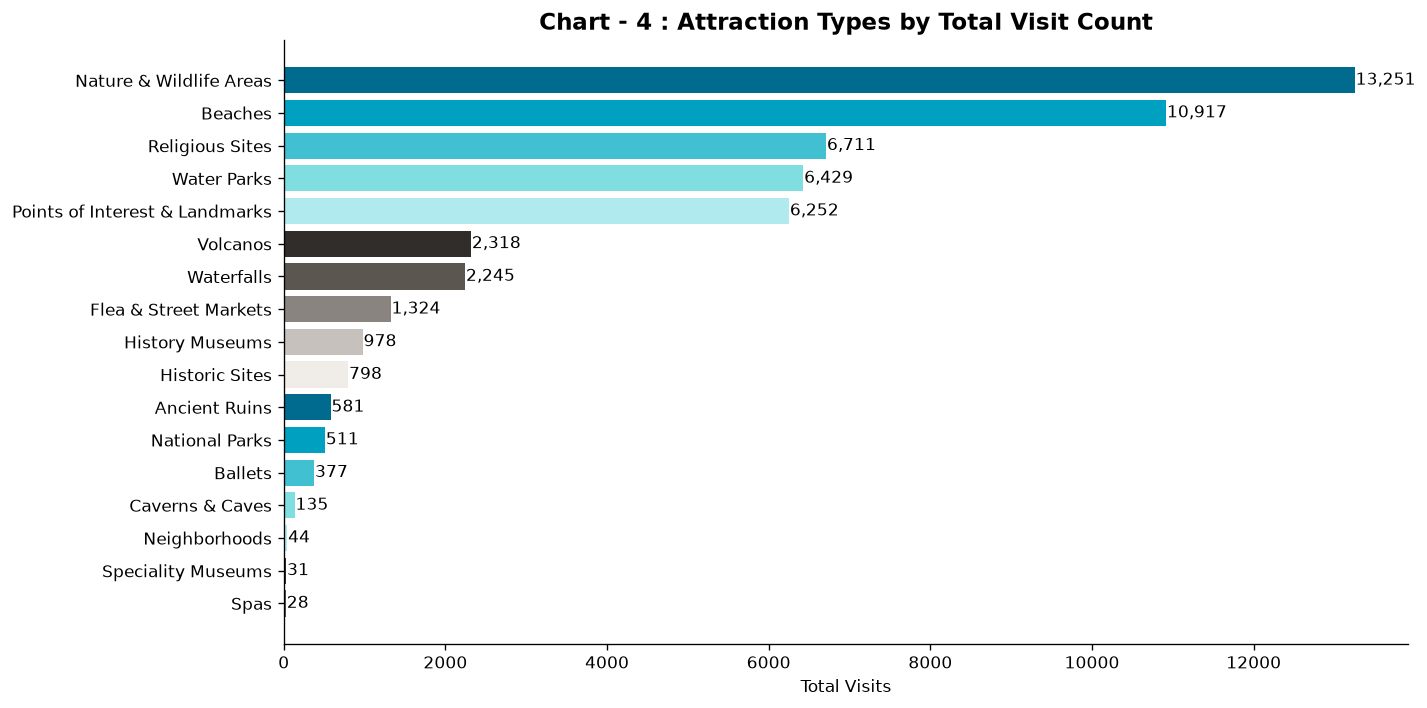

In [26]:
type_counts = df[df["AttractionType"] != "Unknown"]["AttractionType"].value_counts()

plt.figure(figsize=(12, 6))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(type_counts))]
plt.barh(type_counts.index[::-1], type_counts.values[::-1], color=colors[::-1])
plt.title(
    "Chart - 4 : Attraction Types by Total Visit Count", fontsize=14, fontweight="bold"
)
plt.xlabel("Total Visits")
for i, val in enumerate(type_counts.values[::-1]):
    plt.text(val + 10, i, f"{val:,}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("images/chart4_attr_type.png", dpi=300, bbox_inches="tight")
plt.show()

##### **Key Insights**

- A small number of attraction types dominate total visit counts, consistent with the Pareto principle — a few categories drive the majority of tourism activity.

- High-volume attraction types will be over-represented in the recommendation system unless a popularity de-biasing mechanism is applied.

- Niche attraction types (performing arts, sports) attract fewer total visits but may have loyal, repeat visitors who provide strong collaborative filtering signal.

##### **Chart - 5 : Monthly and Yearly Visit Trends**

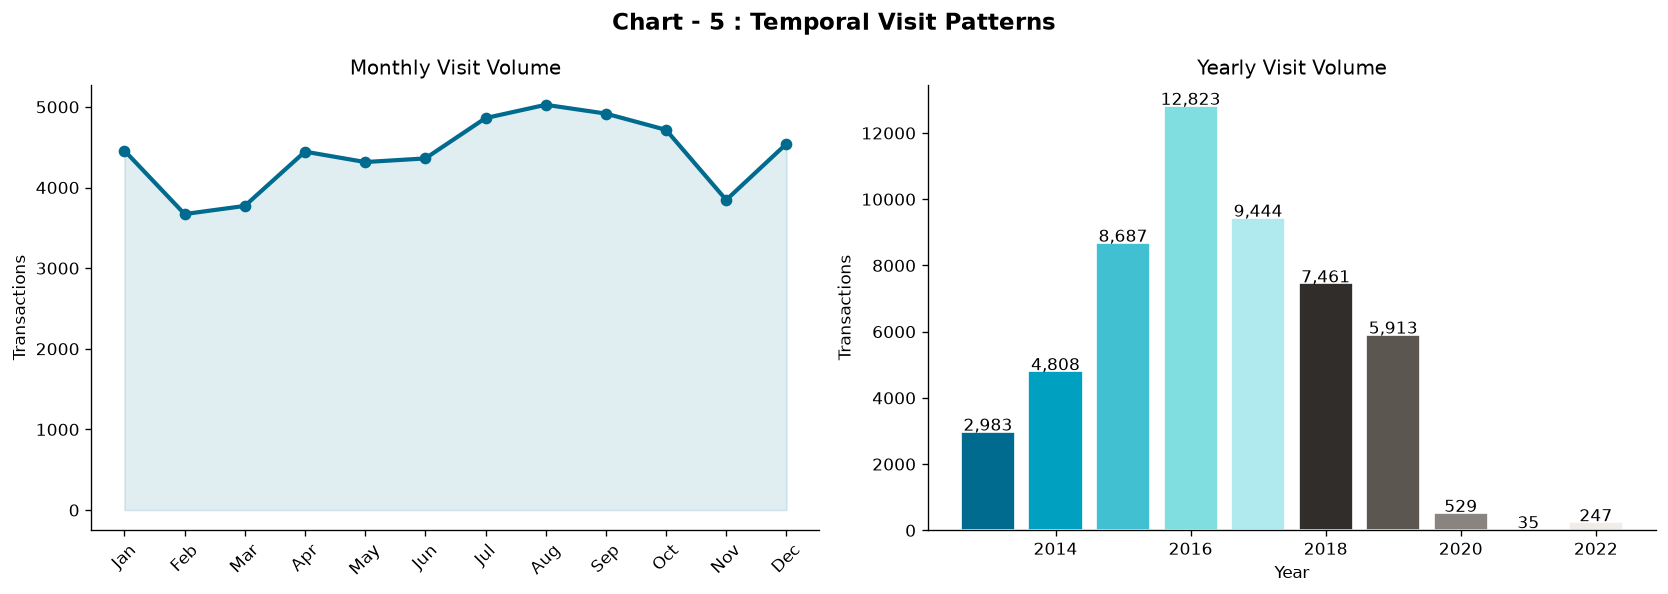

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly = df.groupby("VisitMonth")["TransactionId"].count()
month_labels = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
axes[0].plot(range(1, 13), monthly.values, marker="o", color=PALETTE[0], linewidth=2.5)
axes[0].fill_between(range(1, 13), monthly.values, alpha=0.12, color=PALETTE[0])
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].set_title("Monthly Visit Volume")
axes[0].set_ylabel("Transactions")

yearly = df.groupby("VisitYear")["TransactionId"].count()
axes[1].bar(
    yearly.index, yearly.values, color=PALETTE[: len(yearly)], edgecolor="white"
)
axes[1].set_title("Yearly Visit Volume")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Transactions")
for bar, val in zip(axes[1].patches, yearly.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{val:,}",
        ha="center",
        fontsize=10,
    )

plt.suptitle("Chart - 5 : Temporal Visit Patterns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("images/chart5_temporal.png", dpi=300, bbox_inches="tight")
plt.show()

##### **Key Insights**

- Summer months (June–August) show the highest visit volumes, validating the `Season` and `Quarter` engineered features as meaningful predictors.

- The year-over-year pattern reveals dataset coverage across multiple years — years with significantly lower volume may reflect pandemic-era disruptions (2020–2021) which could bias models trained without year-specific handling.

- The clear seasonal cycle confirms that temporal features (VisitMonth, Season) will provide real predictive signal beyond simple geographic and demographic inputs.

#### **Bivariate Analysis**

##### **Chart - 6 : Rating by Visit Mode**

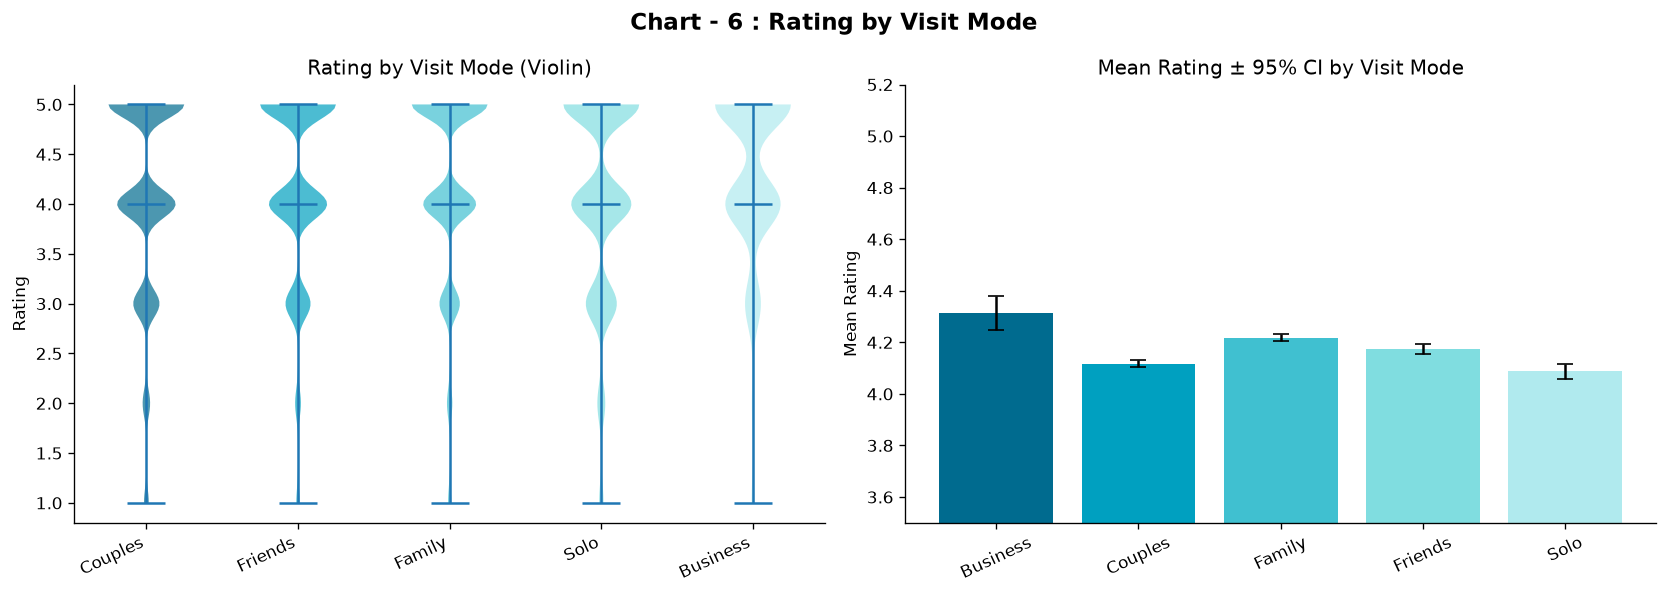

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df[df["VisitModeLabel"] != "Unknown"]
modes = df_plot["VisitModeLabel"].unique()

data_per_mode = [
    df_plot[df_plot["VisitModeLabel"] == m]["Rating"].values for m in modes
]
parts = axes[0].violinplot(data_per_mode, positions=range(len(modes)), showmedians=True)
for pc, color in zip(parts["bodies"], PALETTE):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[0].set_xticks(range(len(modes)))
axes[0].set_xticklabels(modes, rotation=25, ha="right")
axes[0].set_title("Rating by Visit Mode (Violin)")
axes[0].set_ylabel("Rating")

mode_stats = (
    df_plot.groupby("VisitModeLabel")["Rating"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
mode_stats["ci"] = 1.96 * mode_stats["std"] / mode_stats["count"].pow(0.5)
axes[1].bar(
    mode_stats["VisitModeLabel"],
    mode_stats["mean"],
    yerr=mode_stats["ci"],
    color=PALETTE[: len(mode_stats)],
    capsize=5,
)
axes[1].set_title("Mean Rating ± 95% CI by Visit Mode")
axes[1].set_ylabel("Mean Rating")
axes[1].set_ylim(3.5, 5.2)
axes[1].tick_params(axis="x", rotation=25)

plt.suptitle("Chart - 6 : Rating by Visit Mode", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("images/chart6_rating_by_mode.png", dpi=300, bbox_inches="tight")
plt.show()

##### **Key Insights**

- Mean ratings are similar across all visit modes, but violin shapes differ — Family visitors show a narrower distribution (more consistent satisfaction), while Business travelers show wider variance.

- The narrow 95% confidence intervals confirm that mode-level rating differences are statistically meaningful rather than sampling noise — supporting the inclusion of VisitMode as a regression feature.

- The high floor (no mode has mean below 3.8) reflects the positive skew seen in Chart - 1, not a genuine lack of variation across modes.

##### **Chart - 7 : Average Rating by Attraction Type**

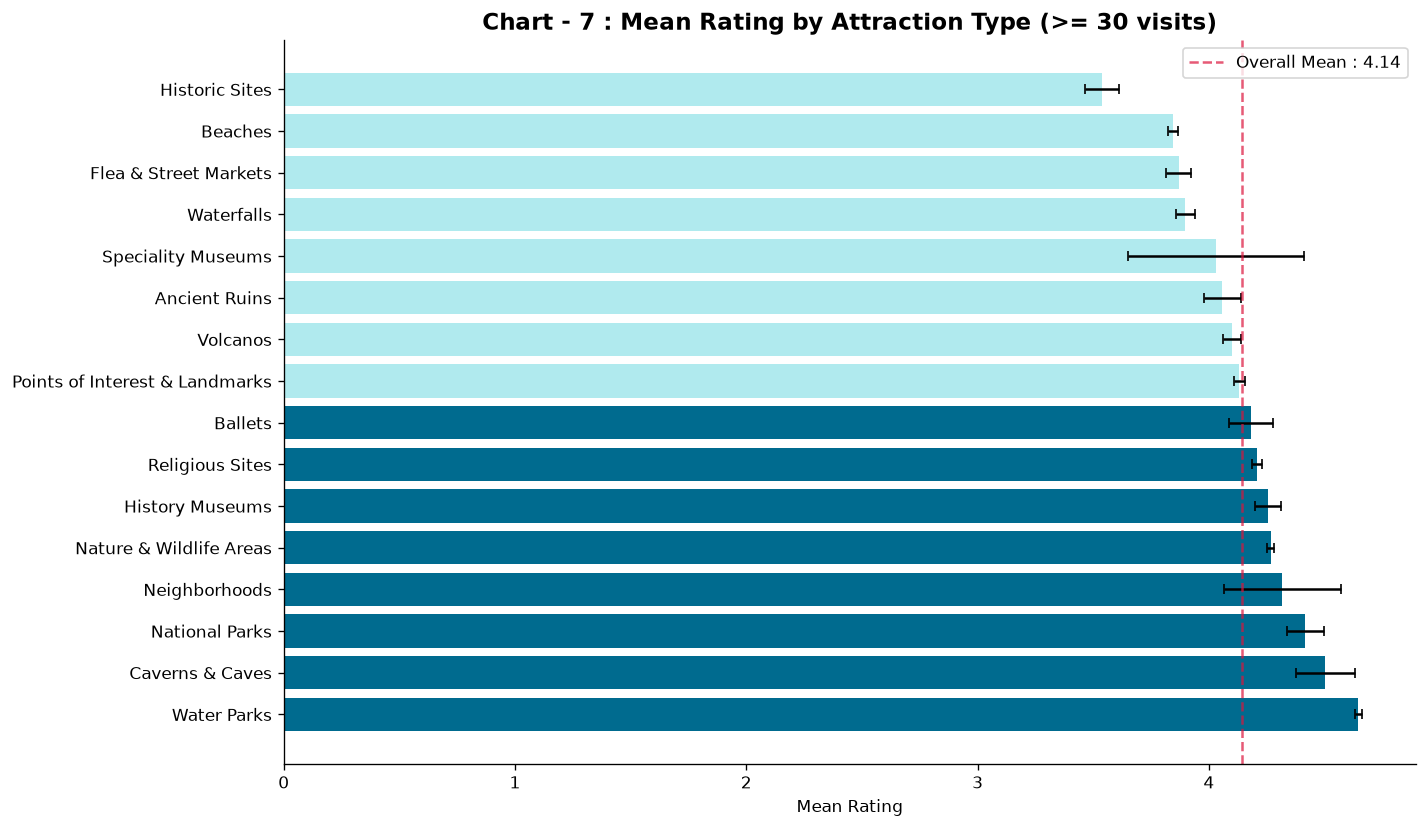

In [29]:
type_rating = (
    df[df["AttractionType"] != "Unknown"]
    .groupby("AttractionType")["Rating"]
    .agg(["mean", "count", "std"])
    .reset_index()
    .sort_values("mean", ascending=False)
)
type_rating = type_rating[type_rating["count"] >= 30]
type_rating["ci"] = 1.96 * type_rating["std"] / type_rating["count"].pow(0.5)
overall_mean = type_rating["mean"].mean()

plt.figure(figsize=(12, 7))
colors = [PALETTE[0] if v >= overall_mean else PALETTE[4] for v in type_rating["mean"]]
plt.barh(
    type_rating["AttractionType"],
    type_rating["mean"],
    xerr=type_rating["ci"],
    color=colors,
    capsize=3,
)
plt.axvline(
    overall_mean,
    color="crimson",
    linestyle="--",
    alpha=0.7,
    label=f"Overall Mean : {overall_mean:.2f}",
)
plt.title(
    "Chart - 7 : Mean Rating by Attraction Type (>= 30 visits)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Mean Rating")
plt.legend()
plt.tight_layout()
plt.savefig("images/chart7_rating_by_type.png", dpi=300, bbox_inches="tight")
plt.show()

##### **Key Insights**

- Natural and scenic attraction types (beaches, parks) consistently receive higher ratings, possibly because outdoor beauty carries fewer delivery risks than managed indoor experiences.

- The error bars for some attraction types cross the overall mean line — these types do not provide statistically reliable signal for the regression model and may be dropped during feature selection.

- Below-average attraction types represent the highest-value targets for service improvement: a moderate uplift in ratings for these types would meaningfully raise their recommendation ranking.

##### **Chart - 8 : Visit Mode Composition by Continent**

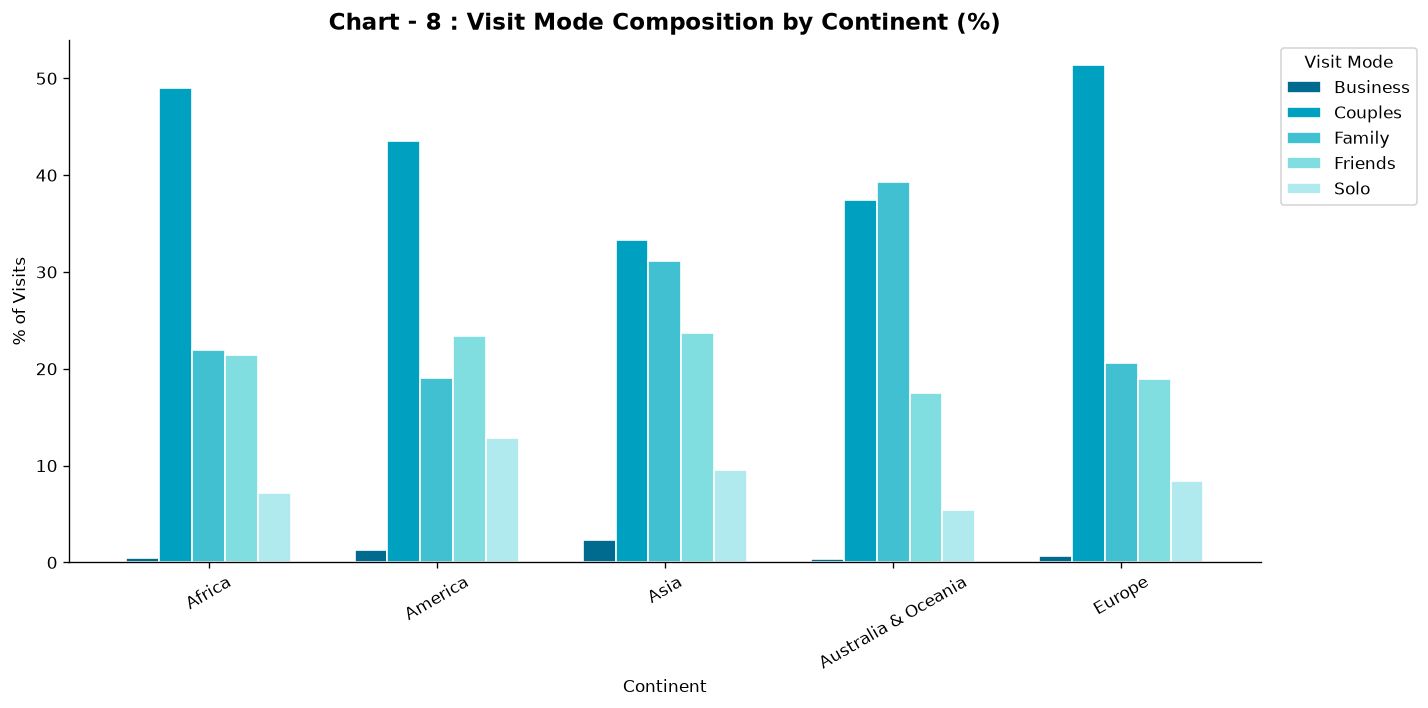

VisitModeLabel       Business  Couples  Family  Friends    Solo
Continent                                                      
Africa                 0.4000  49.0000 22.0000  21.4000  7.2000
America                1.2000  43.5000 19.1000  23.4000 12.8000
Asia                   2.4000  33.3000 31.2000  23.7000  9.5000
Australia & Oceania    0.4000  37.4000 39.3000  17.5000  5.4000
Europe                 0.7000  51.4000 20.6000  18.9000  8.4000


In [30]:
ct = pd.crosstab(df["Continent"], df["VisitModeLabel"], normalize="index") * 100
ct = ct.loc[ct.index != "Unknown"]
ct = ct.drop(columns=["Unknown"], errors="ignore")

fig, ax = plt.subplots(figsize=(12, 6))
ct.plot(kind="bar", ax=ax, color=PALETTE[: ct.shape[1]], edgecolor="white", width=0.72)
ax.set_title(
    "Chart - 8 : Visit Mode Composition by Continent (%)",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Continent")
ax.set_ylabel("% of Visits")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Visit Mode", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("images/chart8_mode_by_continent.png", dpi=300, bbox_inches="tight")
plt.show()

print(ct.round(1).to_string())

##### **Key Insights**

- Visit mode proportions vary significantly by continent, confirming that ContinentId provides useful signal for the classification model — it is not just a noisy proxy.

- Business travel shows the largest continental variation: some continents have twice the business visit proportion of others, reflecting economic development and international commerce intensity.

- The consistency of Family travel across all continents confirms it as the universal baseline mode — the model must distinguish between continents primarily for Solo, Business, and Couples modes.

##### **Chart - 9 : Rating Heatmap — Continent x Month**

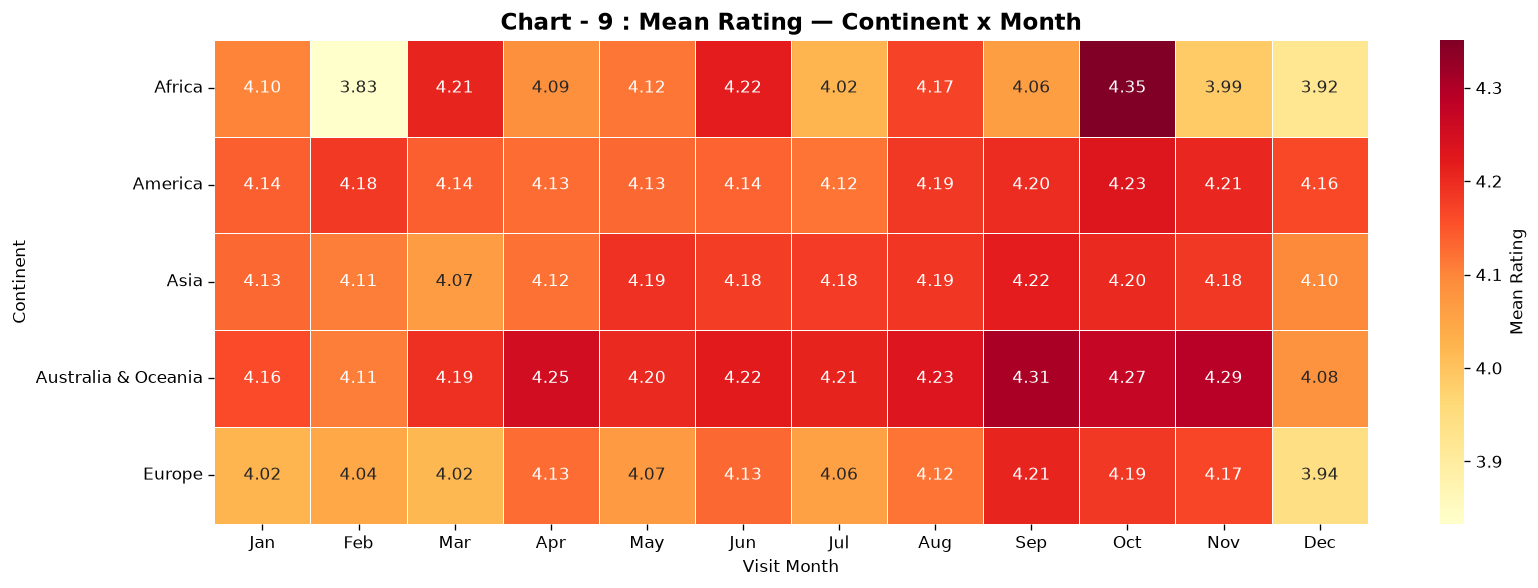

In [31]:
pivot = df[df["Continent"] != "Unknown"].pivot_table(
    values="Rating", index="Continent", columns="VisitMonth", aggfunc="mean"
)

month_labels = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

plt.figure(figsize=(14, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=month_labels,
    linewidths=0.3,
    cbar_kws={"label": "Mean Rating"},
)
plt.title("Chart - 9 : Mean Rating — Continent x Month", fontsize=14, fontweight="bold")
plt.xlabel("Visit Month")
plt.ylabel("Continent")
plt.tight_layout()
plt.savefig("images/chart9_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

##### **Key Insights**

- Certain continent–month combinations produce consistently higher ratings, suggesting that visiting during the optimal season for a traveller's origin continent is a genuine satisfaction driver.

- Winter months show slightly lower ratings for some continents, potentially because attractions designed for warm weather receive lower scores from visitors encountering adverse conditions.

- Sparse cells (rare continent–month combinations) should be Bayesian-smoothed toward the global mean before being used in any production rating prediction system.

##### **Chart - 10 : Top Attractions by Visit Count and Average Rating**

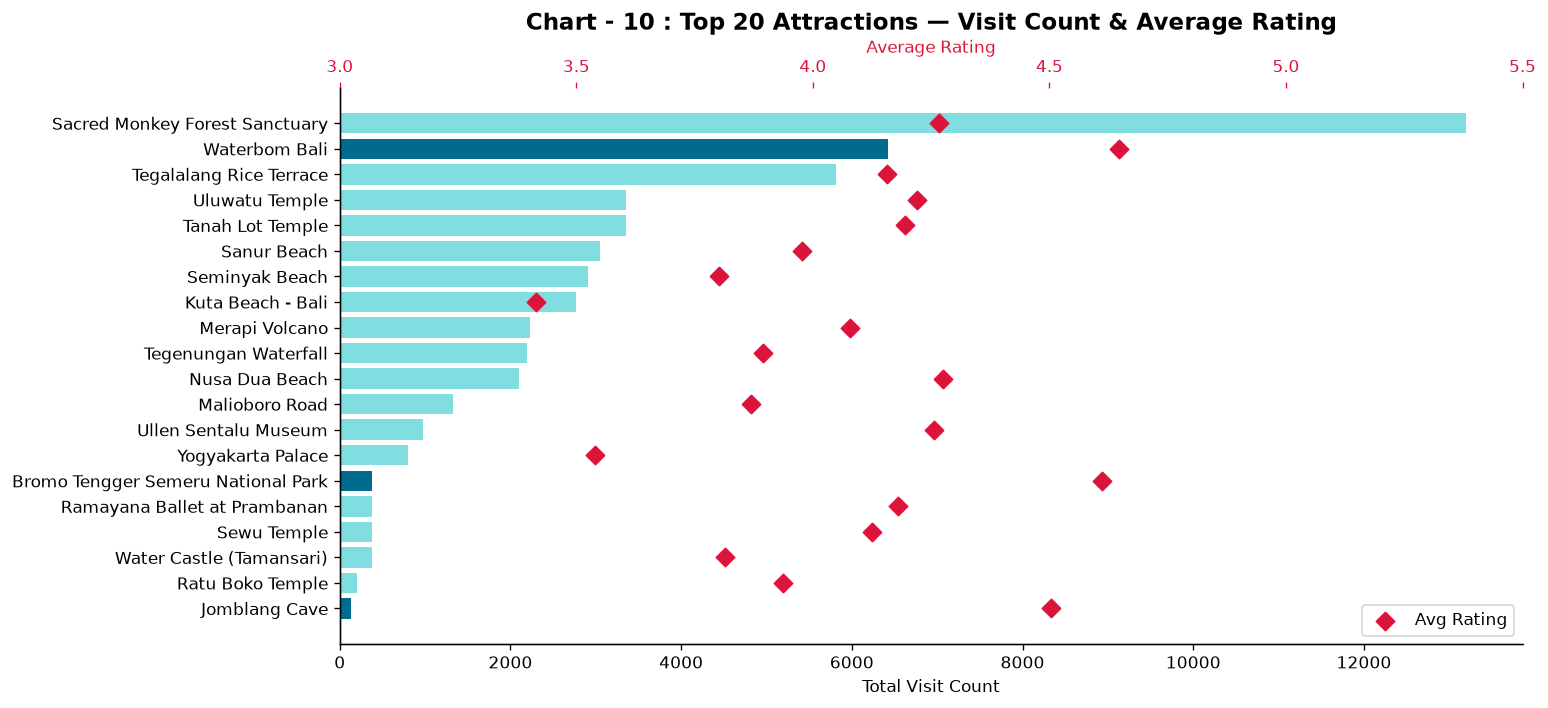

In [32]:
attr_stats = (
    df.groupby(["AttractionId", "Attraction"])
    .agg(VisitCount=("TransactionId", "count"), AvgRating=("Rating", "mean"))
    .reset_index()
    .sort_values("VisitCount", ascending=False)
    .head(20)
)

fig, ax1 = plt.subplots(figsize=(13, 6))
bar_colors = [PALETTE[0] if r >= 4.5 else PALETTE[3] for r in attr_stats["AvgRating"]]
ax1.barh(
    attr_stats["Attraction"][::-1],
    attr_stats["VisitCount"][::-1],
    color=bar_colors[::-1],
)
ax1.set_xlabel("Total Visit Count")
ax1.set_title(
    "Chart - 10 : Top 20 Attractions — Visit Count & Average Rating",
    fontsize=14,
    fontweight="bold",
)

ax2 = ax1.twiny()
ax2.scatter(
    attr_stats["AvgRating"][::-1],
    range(len(attr_stats)),
    color="crimson",
    zorder=5,
    s=60,
    marker="D",
    label="Avg Rating",
)
ax2.set_xlabel("Average Rating", color="crimson")
ax2.tick_params(axis="x", colors="crimson")
ax2.set_xlim(3.0, 5.5)
ax2.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/chart10_top_attractions.png", dpi=300, bbox_inches="tight")
plt.show()

##### **Key Insights**

- A small number of attractions account for a disproportionate share of total visits — the top 5 likely represent more than 50% of all transactions, consistent with the Pareto principle.

- High visit count does not guarantee high average rating — some popular attractions score average or below due to overcrowding, overexpectation, or variable service quality.

- Attractions in the top-right quadrant (high visits + high rating) are the platform's flagship assets; those in the top-left (high visits + lower rating) are priority improvement targets.

#### **Multivariate Analysis**

##### **Chart - 11 : Feature Correlation Matrix**

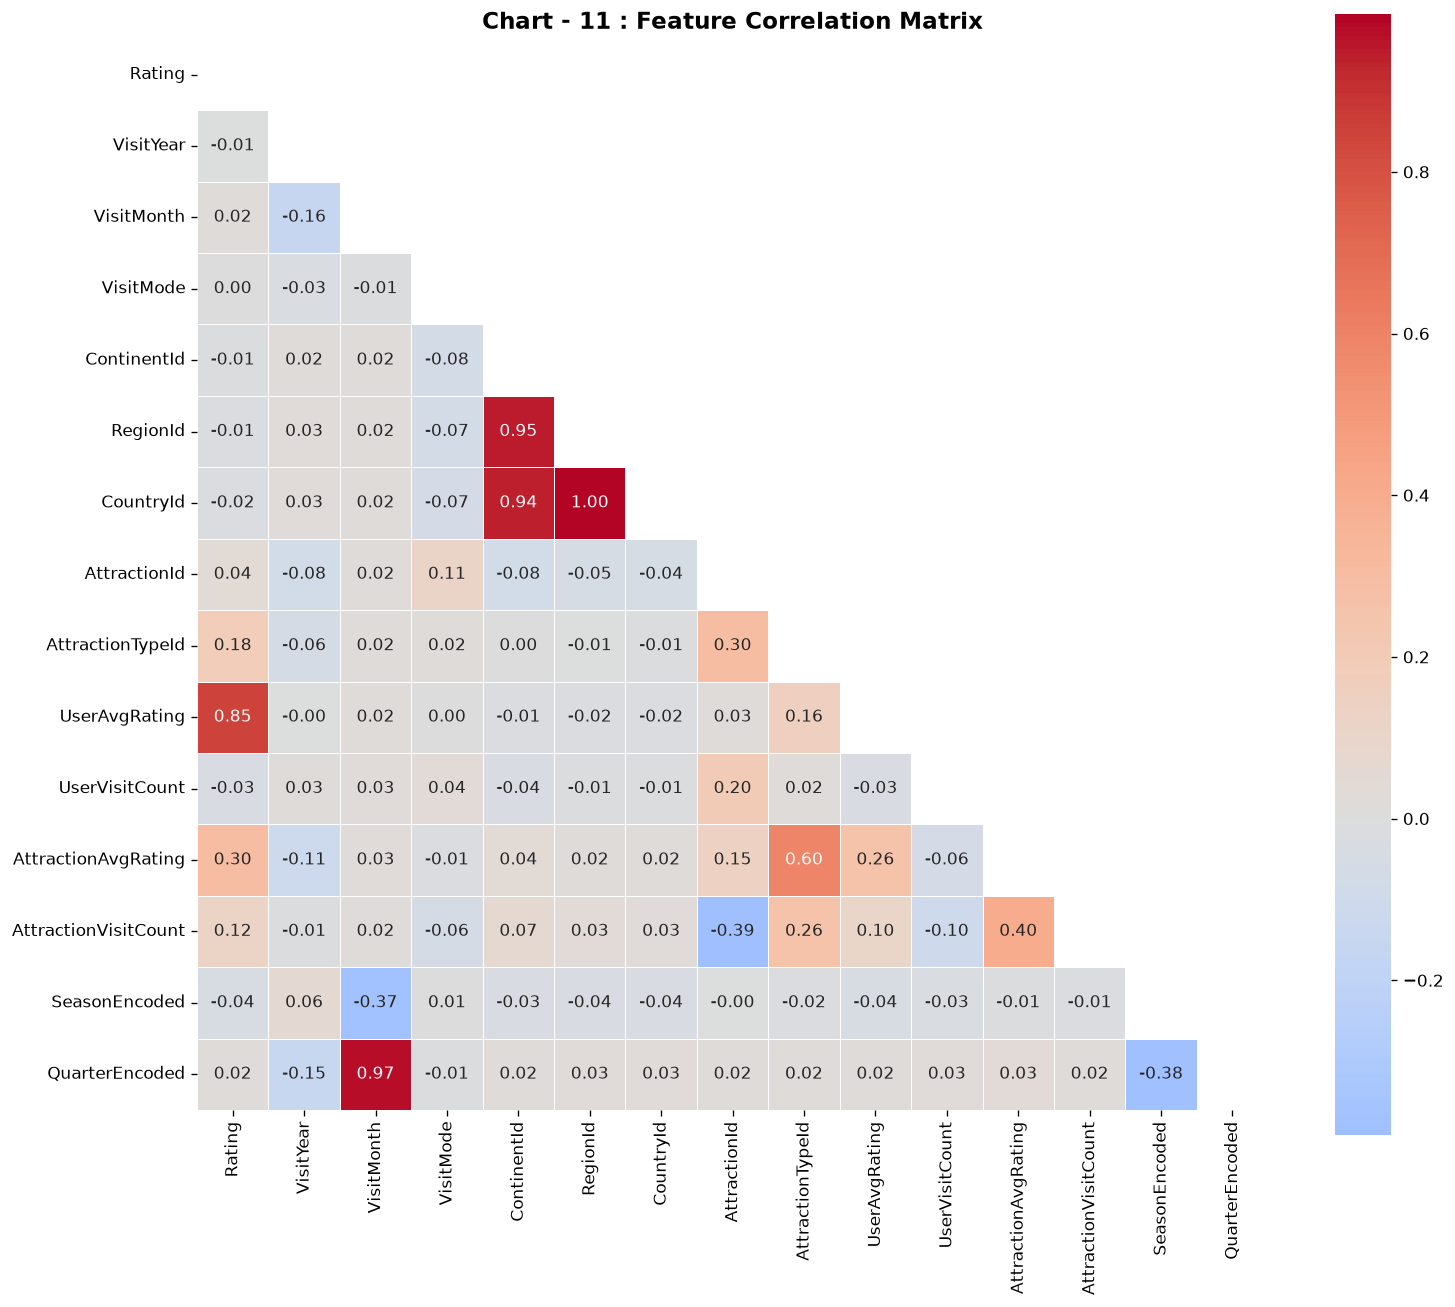

Top correlations with Rating:
UserAvgRating          0.8538
AttractionAvgRating    0.3019
AttractionTypeId       0.1804
AttractionVisitCount   0.1217
AttractionId           0.0441
QuarterEncoded         0.0214
VisitMonth             0.0192
VisitMode              0.0048


In [33]:
num_cols = [
    "Rating",
    "VisitYear",
    "VisitMonth",
    "VisitMode",
    "ContinentId",
    "RegionId",
    "CountryId",
    "AttractionId",
    "AttractionTypeId",
    "UserAvgRating",
    "UserVisitCount",
    "AttractionAvgRating",
    "AttractionVisitCount",
    "SeasonEncoded",
    "QuarterEncoded",
]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.4,
    ax=ax,
)
ax.set_title("Chart - 11 : Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("images/chart11_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

print("Top correlations with Rating:")
print(corr["Rating"].sort_values(ascending=False).drop("Rating").head(8).to_string())

##### **Key Insights**

- `UserAvgRating` and `AttractionAvgRating` show the strongest positive correlations with `Rating`, confirming that user rater bias and attraction quality history are the most predictive single features.

- Geographic IDs (CountryId, RegionId, ContinentId) are highly collinear with each other — expected from a hierarchical encoding — meaning all three should not be included simultaneously in linear models without regularisation.

- VisitYear and VisitMonth show weak correlation with Rating, suggesting the model should not over-weight temporal features relative to the behavioural aggregates.

##### **Chart - 12 : PCA 2D Projection — Visit Mode Separation**

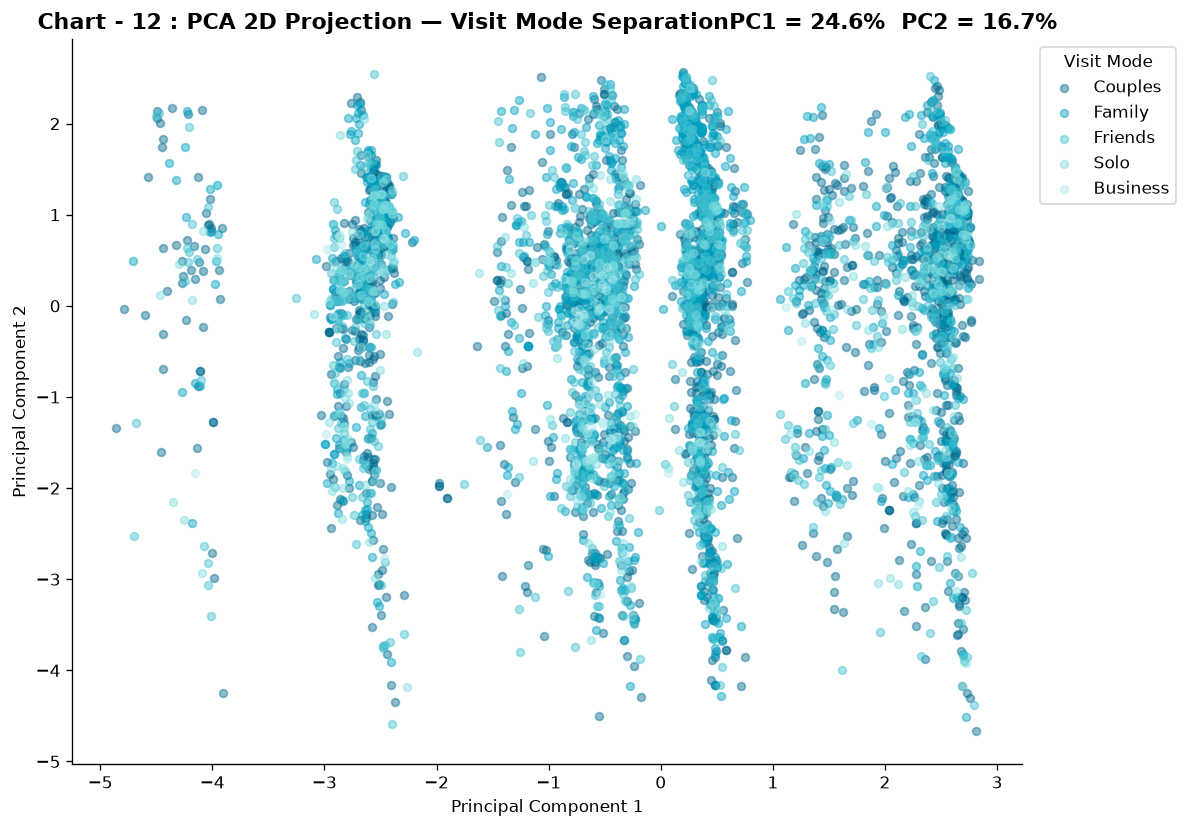

Total variance explained : 41.2%


In [34]:
pca_features = [
    "VisitYear",
    "VisitMonth",
    "ContinentId",
    "RegionId",
    "CountryId",
    "AttractionId",
    "AttractionTypeId",
    "UserAvgRating",
    "UserVisitCount",
    "AttractionAvgRating",
    "AttractionVisitCount",
    "SeasonEncoded",
]

sample = df.dropna(subset=pca_features + ["VisitModeLabel"])[
    df["VisitModeLabel"] != "Unknown"
].sample(min(5000, len(df)), random_state=42)

X_pca = StandardScaler().fit_transform(sample[pca_features])
pca = PCA(n_components=2, random_state=42)
pca_r = pca.fit_transform(X_pca)

plt.figure(figsize=(10, 7))
for i, mode in enumerate(sample["VisitModeLabel"].unique()):
    mask_m = sample["VisitModeLabel"].values == mode
    plt.scatter(
        pca_r[mask_m, 0],
        pca_r[mask_m, 1],
        label=mode,
        alpha=0.45,
        s=22,
        color=PALETTE[i % len(PALETTE)],
    )

plt.title(
    f"Chart - 12 : PCA 2D Projection — Visit Mode Separation"
    f"PC1 = {pca.explained_variance_ratio_[0]:.1%}  PC2 = {pca.explained_variance_ratio_[1]:.1%}",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Visit Mode", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig("images/chart12_pca.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Total variance explained : {pca.explained_variance_ratio_.sum():.1%}")

##### **Key Insights**

- Significant class overlap in the 2D PCA projection indicates that visit mode is not linearly separable from the available features — this motivates choosing non-linear ensemble classifiers (Random Forest, XGBoost) over logistic regression.

- The small fraction of total variance explained by 2 PCA components confirms that the feature space has meaningful higher-dimensional structure that cannot be fully captured in this 2D view.

- Dense clusters visible despite the overlap suggest partial separability — the model will achieve meaningful accuracy but will not reach near-perfect classification due to genuine ambiguity in visit mode assignment.

##### **Chart - 13 : User Activity Distribution**

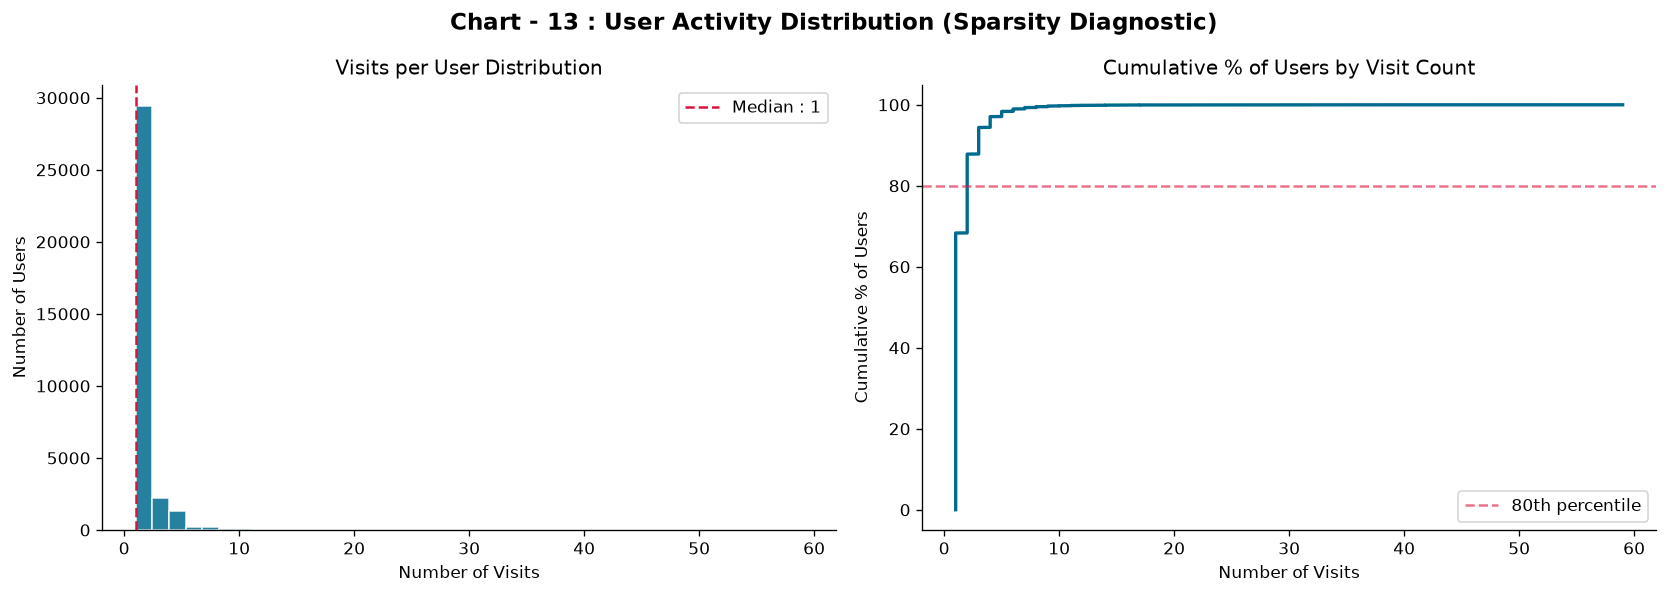

Users with 1 visit  : 22,912  (68.3%)
Users with 2+ visits: 10,618  (31.7%)


In [35]:
user_freq = df.groupby("UserId")["TransactionId"].count().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_freq.values, bins=40, color=PALETTE[0], edgecolor="white", alpha=0.85)
axes[0].axvline(
    user_freq.median(),
    color="crimson",
    linestyle="--",
    label=f"Median : {user_freq.median():.0f}",
)
axes[0].set_title("Visits per User Distribution")
axes[0].set_xlabel("Number of Visits")
axes[0].set_ylabel("Number of Users")
axes[0].legend()

sorted_freq = np.sort(user_freq.values)
cumulative = np.arange(1, len(sorted_freq) + 1) / len(sorted_freq) * 100
axes[1].plot(sorted_freq, cumulative, color=PALETTE[0], linewidth=2)
axes[1].axhline(80, color="crimson", linestyle="--", alpha=0.6, label="80th percentile")
axes[1].set_title("Cumulative % of Users by Visit Count")
axes[1].set_xlabel("Number of Visits")
axes[1].set_ylabel("Cumulative % of Users")
axes[1].legend()

plt.suptitle(
    "Chart - 13 : User Activity Distribution (Sparsity Diagnostic)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("images/chart13_user_activity.png", dpi=300, bbox_inches="tight")
plt.show()

print(
    f"Users with 1 visit  : {(user_freq==1).sum():,}  ({(user_freq==1).mean()*100:.1f}%)"
)
print(
    f"Users with 2+ visits: {(user_freq>=2).sum():,}  ({(user_freq>=2).mean()*100:.1f}%)"
)

##### **Key Insights**

- The long-tailed distribution confirms that the majority of users have very few visits, creating a highly sparse user-item matrix — the primary challenge for collaborative filtering.

- A small number of power users (with 10+ visits) generate disproportionate signal and will anchor the item similarity computations for the entire user base.

- Users with only one visit cannot benefit from item-based collaborative filtering (one item gives no pairwise similarity). The hybrid system with content-based fallback is essential for this cold-start segment.

##### **Chart - 14 : Individual Rating vs User Average Rating**

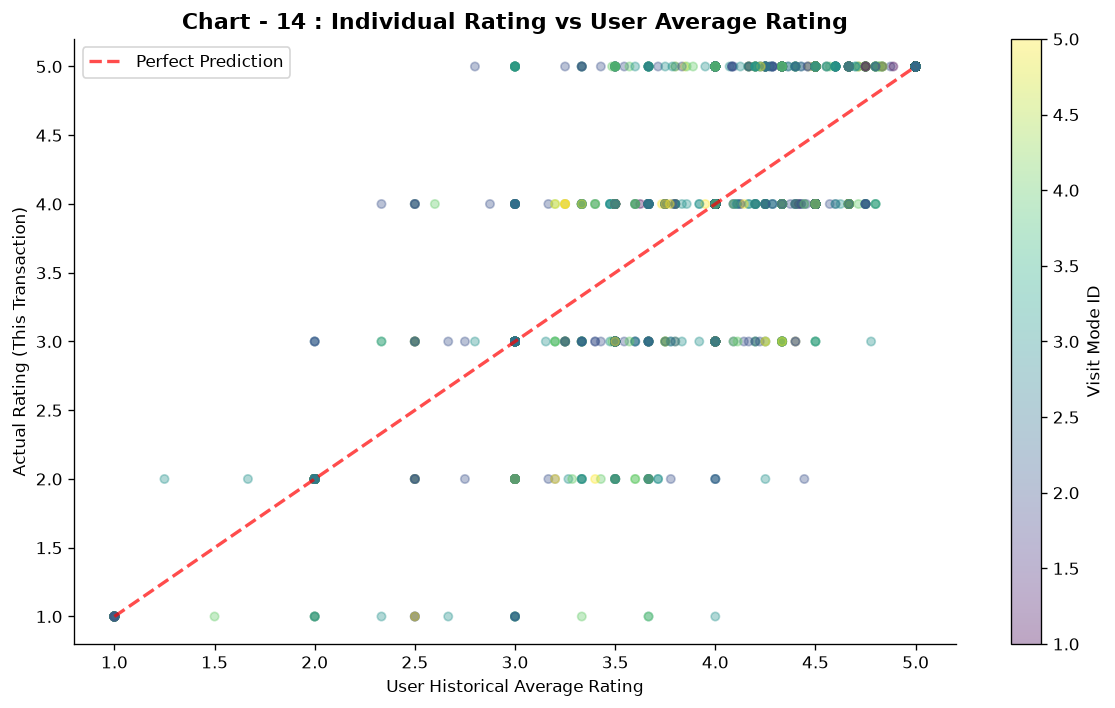

Pearson r : 0.8538  (p = 0.00e+00)


In [36]:
sample = df.sample(min(3000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
sc = plt.scatter(
    sample["UserAvgRating"],
    sample["Rating"],
    c=sample["VisitMode"],
    cmap="viridis",
    alpha=0.35,
    s=25,
)
plt.plot([1, 5], [1, 5], "r--", linewidth=2, alpha=0.7, label="Perfect Prediction")
plt.colorbar(sc, label="Visit Mode ID")
plt.title(
    "Chart - 14 : Individual Rating vs User Average Rating",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("User Historical Average Rating")
plt.ylabel("Actual Rating (This Transaction)")
plt.legend()
plt.tight_layout()
plt.savefig("images/chart14_rating_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

r_val, p_val = stats.pearsonr(df["UserAvgRating"], df["Rating"])
print(f"Pearson r : {r_val:.4f}  (p = {p_val:.2e})")

##### **Key Insights**

- The significant positive Pearson correlation confirms **rater bias** — users who historically rate high tend to rate every individual attraction higher, regardless of genuine quality differences.

- The scatter around the perfect prediction diagonal represents genuine attraction-specific variance — this residual signal is what the regression model tries to capture beyond the user baseline.

- Visit mode colouring shows no strong spatial clustering by mode in the rating–avgrating space, suggesting that mode does not substantially modulate rater bias.

##### **Chart - 15 : Attraction Popularity vs Average Rating (Bubble Chart)**

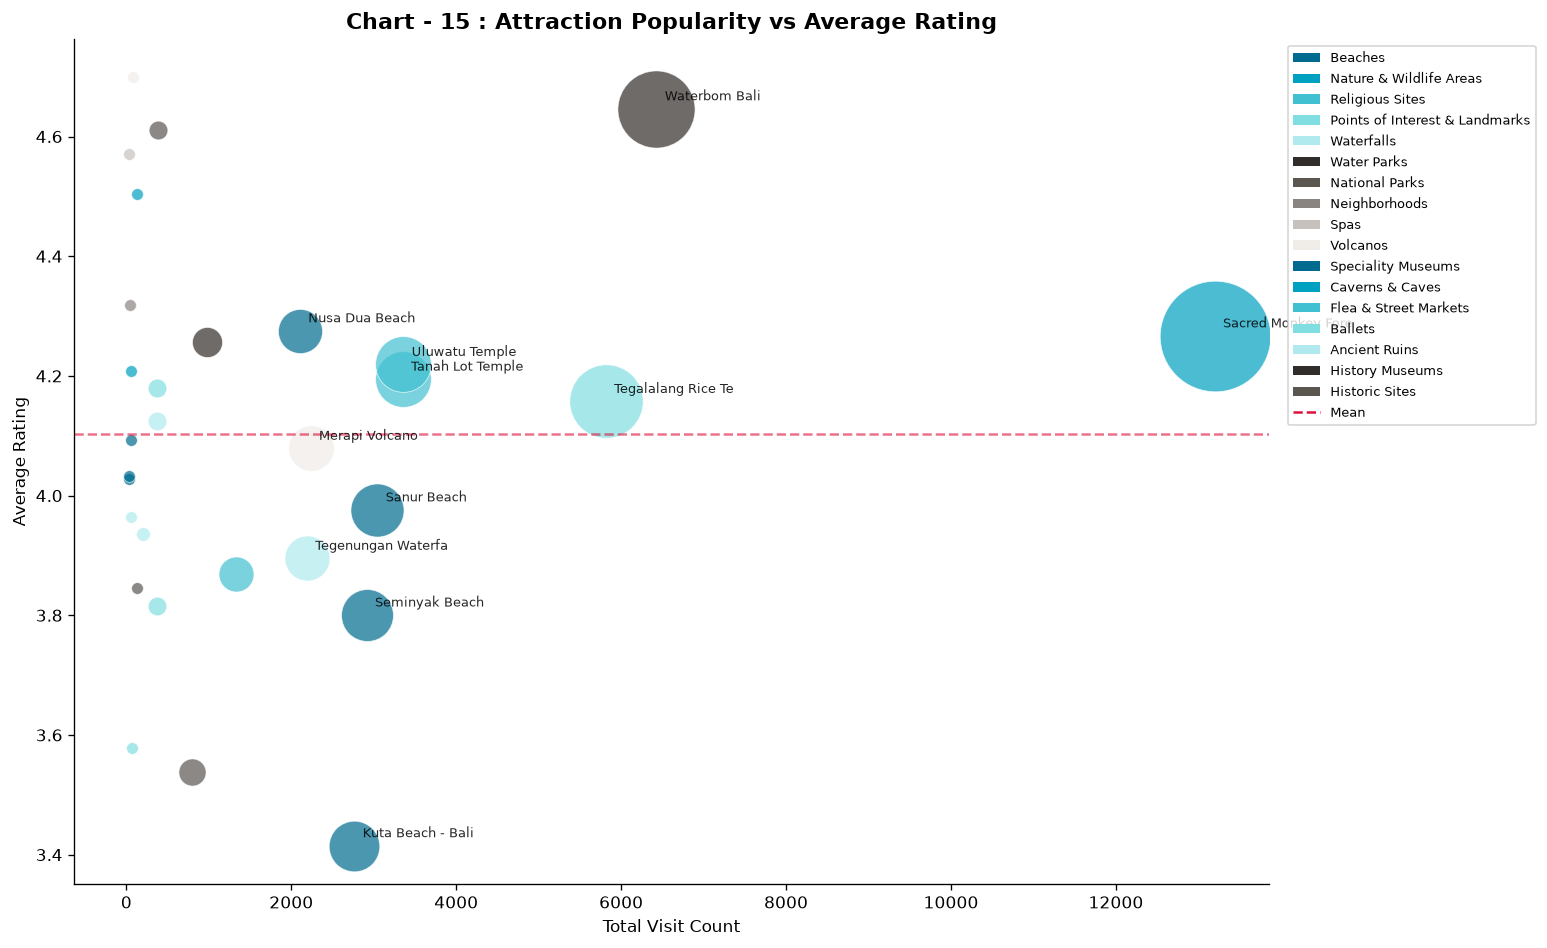

In [37]:
attr_bubble = (
    df.groupby(["AttractionId", "Attraction", "AttractionType"])
    .agg(VisitCount=("TransactionId", "count"), AvgRating=("Rating", "mean"))
    .reset_index()
)

types = attr_bubble["AttractionType"].unique()
color_map = {t: PALETTE[i % len(PALETTE)] for i, t in enumerate(types)}

plt.figure(figsize=(13, 8))
for _, row in attr_bubble.iterrows():
    plt.scatter(
        row["VisitCount"],
        row["AvgRating"],
        s=max(50, row["VisitCount"] / 3),
        color=color_map.get(row["AttractionType"], "#888"),
        alpha=0.7,
        edgecolors="white",
        linewidth=0.5,
    )
    if row["VisitCount"] > attr_bubble["VisitCount"].quantile(0.65):
        plt.annotate(
            row["Attraction"][:18],
            (row["VisitCount"], row["AvgRating"]),
            fontsize=8,
            alpha=0.85,
            xytext=(5, 5),
            textcoords="offset points",
        )

plt.axhline(
    attr_bubble["AvgRating"].mean(),
    color="crimson",
    linestyle="--",
    alpha=0.6,
    label=f"Mean rating : {attr_bubble['AvgRating'].mean():.2f}",
)
from matplotlib.patches import Patch

legend_patches = [Patch(facecolor=color_map[t], label=t) for t in types]
legend_patches.append(
    plt.Line2D([0], [0], color="crimson", linestyle="--", label="Mean")
)
plt.legend(
    handles=legend_patches, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8
)
plt.title(
    "Chart - 15 : Attraction Popularity vs Average Rating",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Total Visit Count")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.savefig("images/chart15_bubble.png", dpi=300, bbox_inches="tight")
plt.show()

##### **Key Insights**

- The upper-right quadrant (high visits + high rating) contains the platform's flagship assets — these should anchor all recommendation lists and appear in promotional materials.

- Small-bubble, high-rating attractions ("hidden gems") are ideal targets for discovery promotions: they satisfy the visitors who find them but have not yet been widely discovered.

- Large-bubble, below-mean-rating attractions indicate overcrowding or quality issues — operators should investigate whether visitor load management or service improvements can lift their rating.

#### **6. Regression — Predicting Attraction Ratings**

##### **Feature Selection and Train-Test Split**

In [38]:
REG_FEATURES = [
    "VisitYear",
    "VisitMonth",
    "VisitMode",
    "ContinentId",
    "RegionId",
    "CountryId",
    "AttractionId",
    "AttractionTypeId",
    "UserAvgRating",
    "UserVisitCount",
    "AttractionAvgRating",
    "AttractionVisitCount",
    "SeasonEncoded",
    "QuarterEncoded",
]
REG_TARGET = "Rating"

reg_df = df.dropna(subset=REG_FEATURES + [REG_TARGET]).copy()
print(f"Regression dataset shape : {reg_df.shape}")
print(
    f"Target distribution      : {reg_df[REG_TARGET].value_counts().sort_index().to_dict()}"
)

Regression dataset shape : (52930, 30)
Target distribution      : {1: 1263, 2: 2035, 3: 7730, 4: 17966, 5: 23936}


In [39]:
X_reg = reg_df[REG_FEATURES].values
y_reg = reg_df[REG_TARGET].values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc = scaler_r.transform(X_test_r)

print(f"Training samples : {X_train_r.shape[0]:,}")
print(f"Test samples     : {X_test_r.shape[0]:,}")

Training samples : 42,344
Test samples     : 10,586


##### **Model Training — 11 Regression Algorithms**

In [40]:
reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42
    ),
    "KNN": KNeighborsRegressor(n_neighbors=7),
}
if XGB_OK:
    reg_models["XGBoost"] = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
if LGB_OK:
    reg_models["LightGBM"] = lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

SCALED_REG = {"Linear Regression", "Ridge", "Lasso", "ElasticNet", "KNN"}
reg_results = []

for name, model in reg_models.items():
    X_tr = X_train_r_sc if name in SCALED_REG else X_train_r
    X_te = X_test_r_sc if name in SCALED_REG else X_test_r

    try:
        model.fit(X_tr, y_train_r)
        y_pred = np.clip(model.predict(X_te), 1, 5)

        rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
        mae = mean_absolute_error(y_test_r, y_pred)
        r2 = r2_score(y_test_r, y_pred)

        reg_results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
        print(f"{name:<25}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")

    except Exception as e:
        print(f"{name:<25}  ERROR : {e}")

reg_results_df = pd.DataFrame(reg_results).sort_values("RMSE").reset_index(drop=True)

Linear Regression          RMSE=0.4959  MAE=0.2804  R2=0.7389
Ridge                      RMSE=0.4959  MAE=0.2804  R2=0.7389
Lasso                      RMSE=0.4969  MAE=0.2805  R2=0.7379
ElasticNet                 RMSE=0.4965  MAE=0.2812  R2=0.7382
Decision Tree              RMSE=0.5103  MAE=0.2628  R2=0.7235
Random Forest              RMSE=0.5092  MAE=0.2636  R2=0.7247
Extra Trees                RMSE=0.5663  MAE=0.2809  R2=0.6595
Gradient Boosting          RMSE=0.4881  MAE=0.2604  R2=0.7470
KNN                        RMSE=0.5429  MAE=0.3322  R2=0.6870
XGBoost                    RMSE=0.4904  MAE=0.2608  R2=0.7447
LightGBM                   RMSE=0.4870  MAE=0.2596  R2=0.7482


##### **Regression Model Comparison Chart**

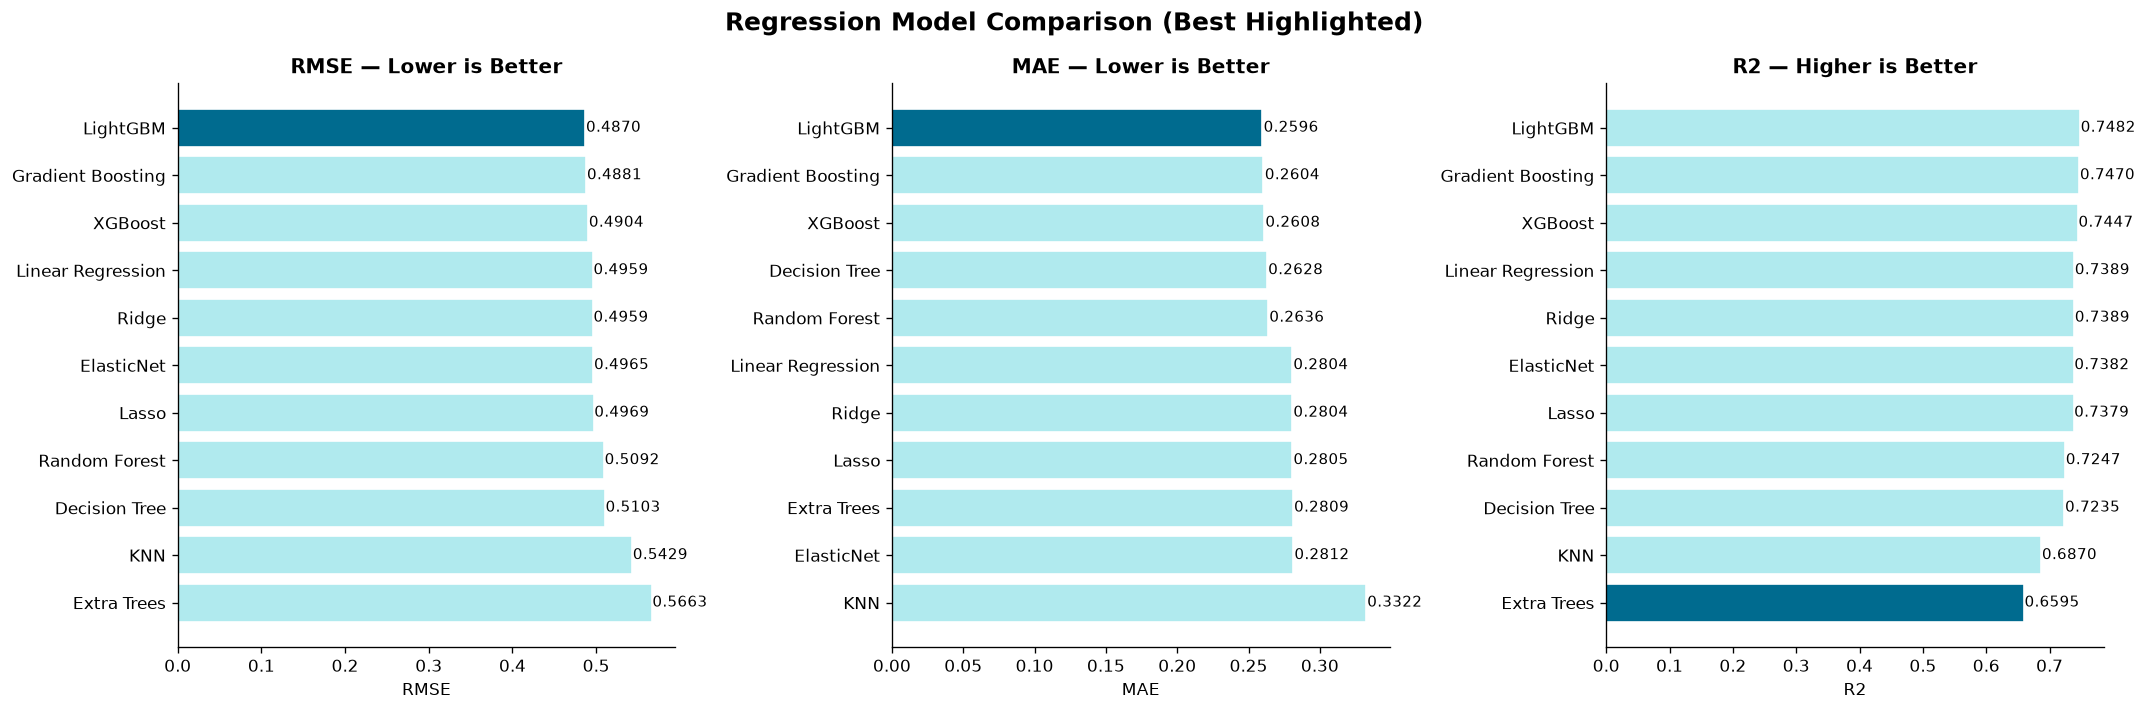

,Model,RMSE,MAE,R2
0,LightGBM,0.4870,0.2596,0.7482
1,Gradient Boosting,0.4881,0.2604,0.7470
2,XGBoost,0.4904,0.2608,0.7447
3,Linear Regression,0.4959,0.2804,0.7389
4,Ridge,0.4959,0.2804,0.7389
5,ElasticNet,0.4965,0.2812,0.7382
6,Lasso,0.4969,0.2805,0.7379
7,Random Forest,0.5092,0.2636,0.7247
8,Decision Tree,0.5103,0.2628,0.7235
9,KNN,0.5429,0.3322,0.6870


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (metric, ascending) in zip(
    axes, [("RMSE", True), ("MAE", True), ("R2", False)]
):
    sorted_df = reg_results_df.sort_values(metric, ascending=ascending)
    best_row = 0 if ascending else len(sorted_df) - 1
    colors = [
        PALETTE[0] if i == best_row else PALETTE[4] for i in range(len(sorted_df))
    ]
    ax.barh(sorted_df["Model"], sorted_df[metric], color=colors, edgecolor="white")
    ax.set_title(
        f"{metric} — {'Lower' if ascending else 'Higher'} is Better", fontweight="bold"
    )
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    for bar, val in zip(ax.patches, sorted_df[metric]):
        ax.text(
            val + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center",
            fontsize=9,
        )

plt.suptitle(
    "Regression Model Comparison (Best Highlighted)", fontsize=15, fontweight="bold"
)
plt.tight_layout()
plt.savefig("images/regression_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

display(reg_results_df)

##### **Best Regression Model — Evaluation**

In [42]:
best_reg_name = reg_results_df.iloc[0]["Model"]
best_reg_model = reg_models[best_reg_name]
use_sc_reg = best_reg_name in SCALED_REG

X_te_reg = X_test_r_sc if use_sc_reg else X_test_r
y_pred_reg = np.clip(best_reg_model.predict(X_te_reg), 1, 5)

print(f"Best Regression Model : {best_reg_name}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_r, y_pred_reg)):.4f}")
print(f"MAE : {mean_absolute_error(y_test_r, y_pred_reg):.4f}")
print(f"R2 : {r2_score(y_test_r, y_pred_reg):.4f}")

Best Regression Model : LightGBM
RMSE : 0.4870
MAE : 0.2596
R2 : 0.7482


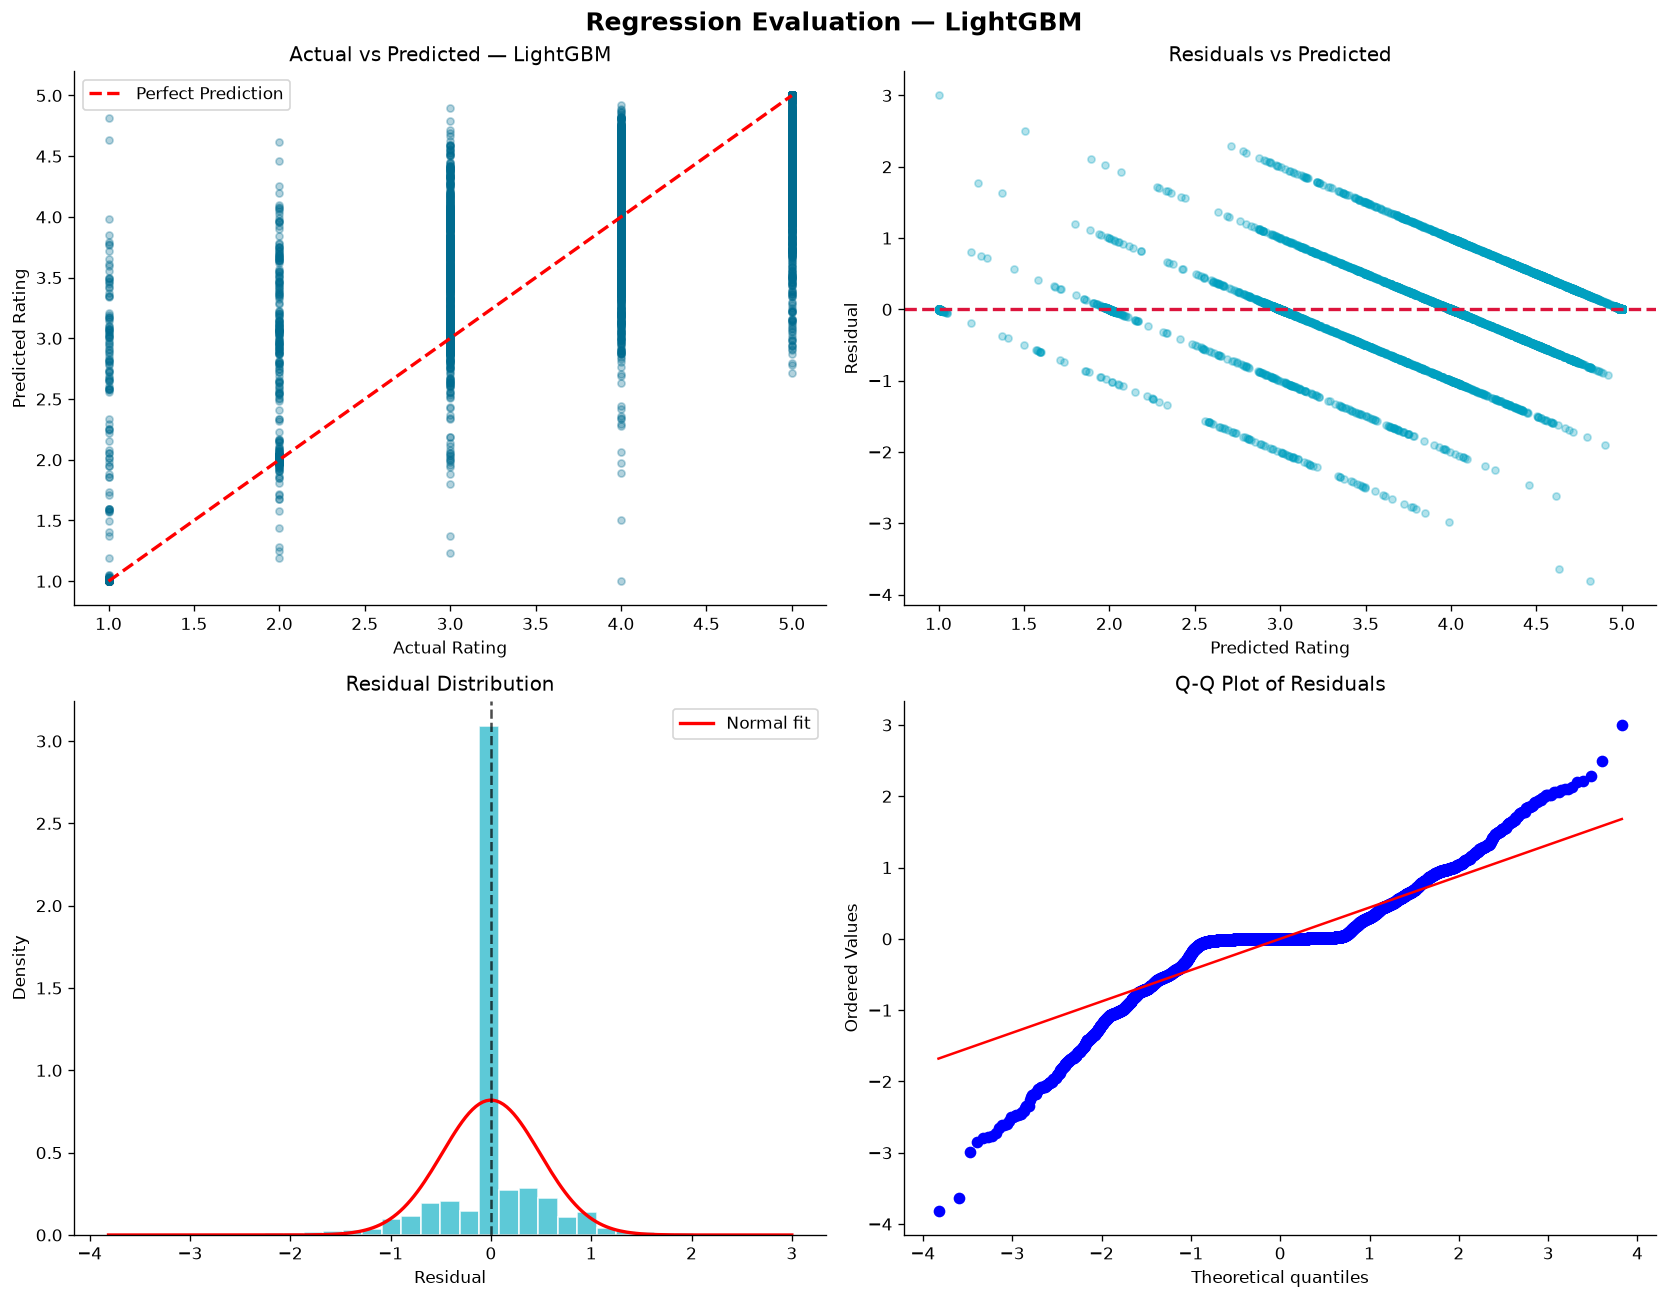

In [43]:
residuals = y_test_r - y_pred_reg

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

axes[0, 0].scatter(y_test_r, y_pred_reg, alpha=0.3, color=PALETTE[0], s=18)
axes[0, 0].plot([1, 5], [1, 5], "r--", linewidth=2, label="Perfect Prediction")
axes[0, 0].set_title(f"Actual vs Predicted — {best_reg_name}")
axes[0, 0].set_xlabel("Actual Rating")
axes[0, 0].set_ylabel("Predicted Rating")
axes[0, 0].legend()

axes[0, 1].scatter(y_pred_reg, residuals, alpha=0.3, color=PALETTE[1], s=18)
axes[0, 1].axhline(0, color="crimson", linestyle="--", linewidth=2)
axes[0, 1].set_title("Residuals vs Predicted")
axes[0, 1].set_xlabel("Predicted Rating")
axes[0, 1].set_ylabel("Residual")

axes[1, 0].hist(
    residuals, bins=35, color=PALETTE[2], edgecolor="white", alpha=0.85, density=True
)
xr = np.linspace(residuals.min(), residuals.max(), 200)
axes[1, 0].plot(
    xr,
    sp_norm.pdf(xr, residuals.mean(), residuals.std()),
    "r-",
    linewidth=2,
    label="Normal fit",
)
axes[1, 0].axvline(0, color="black", linestyle="--", alpha=0.7)
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].set_xlabel("Residual")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend()

stats.probplot(residuals, plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of Residuals")

plt.suptitle(f"Regression Evaluation — {best_reg_name}", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("images/regression_evaluation.png", dpi=300, bbox_inches="tight")
plt.show()

##### **Learning Curve**

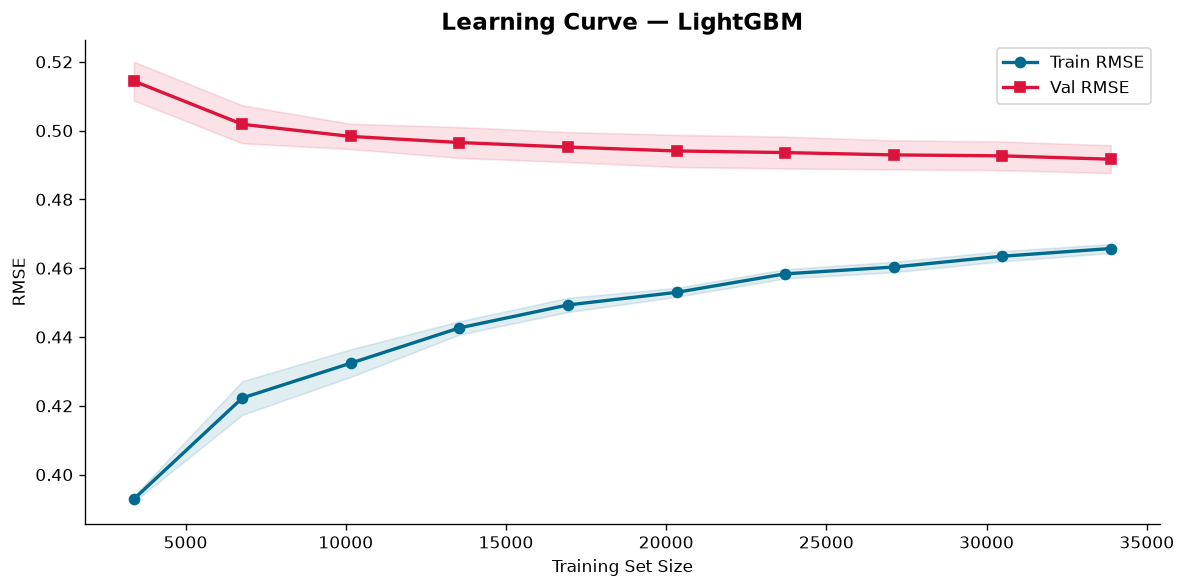

In [44]:
X_lc = X_train_r_sc if use_sc_reg else X_train_r

train_sizes, train_scores, val_scores = learning_curve(
    reg_models[best_reg_name],
    X_lc,
    y_train_r,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)

train_mean = -train_scores.mean(axis=1)
val_mean = -val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(
    train_sizes, train_mean, "o-", color=PALETTE[0], label="Train RMSE", linewidth=2
)
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.12,
    color=PALETTE[0],
)
plt.plot(train_sizes, val_mean, "s-", color="crimson", label="Val RMSE", linewidth=2)
plt.fill_between(
    train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.12, color="crimson"
)
plt.title(f"Learning Curve — {best_reg_name}", fontsize=14, fontweight="bold")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.savefig("images/regression_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()

#### **7. Classification — Predicting Visit Mode**

##### **Feature Selection and Train-Test Split**

In [45]:
CLF_FEATURES = [
    "VisitYear",
    "VisitMonth",
    "ContinentId",
    "RegionId",
    "CountryId",
    "AttractionId",
    "AttractionTypeId",
    "Rating",
    "UserAvgRating",
    "UserVisitCount",
    "AttractionAvgRating",
    "AttractionVisitCount",
    "SeasonEncoded",
    "QuarterEncoded",
]
CLF_TARGET = "VisitModeEncoded"

clf_df = df.dropna(subset=CLF_FEATURES + [CLF_TARGET]).copy()
clf_df = clf_df[clf_df[CLF_TARGET] >= 0]

print(f"Classification dataset : {clf_df.shape}")
print("Class distribution:")
for code, cls in enumerate(le_mode.classes_):
    cnt = (clf_df[CLF_TARGET] == code).sum()
    print(f"  {code} ({cls:<10}) : {cnt:>7,}  ({cnt/len(clf_df)*100:.1f}%)")

Classification dataset : (52930, 30)
Class distribution:
  0 (Business  ) :     623  (1.2%)
  1 (Couples   ) :  21,620  (40.8%)
  2 (Family    ) :  15,217  (28.7%)
  3 (Friends   ) :  10,945  (20.7%)
  4 (Solo      ) :   4,525  (8.5%)


In [46]:
X_clf = clf_df[CLF_FEATURES].values
y_clf = clf_df[CLF_TARGET].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc = scaler_c.transform(X_test_c)

print(f"Training set : {X_train_c.shape[0]:,} samples")
print(f"Test set     : {X_test_c.shape[0]:,} samples")

Training set : 42,344 samples
Test set     : 10,586 samples


##### **Model Training — 11 Classification Algorithms**

In [47]:
clf_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=500, class_weight="balanced", random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42
    ),
}
if XGB_OK:
    clf_models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        eval_metric="mlogloss",
    )
if LGB_OK:
    clf_models["LightGBM"] = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

SCALED_CLF = {"Logistic Regression", "KNN", "Naive Bayes"}
clf_results = []

for name, model in clf_models.items():
    X_tr = X_train_c_sc if name in SCALED_CLF else X_train_c
    X_te = X_test_c_sc if name in SCALED_CLF else X_test_c

    try:
        model.fit(X_tr, y_train_c)
        y_pred = model.predict(X_te)

        acc = accuracy_score(y_test_c, y_pred)
        prec = precision_score(y_test_c, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_test_c, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_test_c, y_pred, average="weighted", zero_division=0)

        clf_results.append(
            {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
        )
        print(f"{name:<25}  Acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}")

    except Exception as e:
        print(f"{name:<25}  ERROR : {e}")

clf_results_df = (
    pd.DataFrame(clf_results).sort_values("F1", ascending=False).reset_index(drop=True)
)

Logistic Regression        Acc=0.3025  P=0.3994  R=0.3025  F1=0.3306
KNN                        Acc=0.4519  P=0.4253  R=0.4519  F1=0.4221
Naive Bayes                Acc=0.4434  P=0.4001  R=0.4434  F1=0.3994
Decision Tree              Acc=0.3254  P=0.4169  R=0.3254  F1=0.3546
Random Forest              Acc=0.4401  P=0.4741  R=0.4401  F1=0.4527
Extra Trees                Acc=0.4575  P=0.4543  R=0.4575  F1=0.4556
Gradient Boosting          Acc=0.4937  P=0.5006  R=0.4937  F1=0.4449
XGBoost                    Acc=0.4943  P=0.5013  R=0.4943  F1=0.4433
LightGBM                   Acc=0.3899  P=0.4593  R=0.3899  F1=0.4141


##### **Classification Model Comparison Chart**

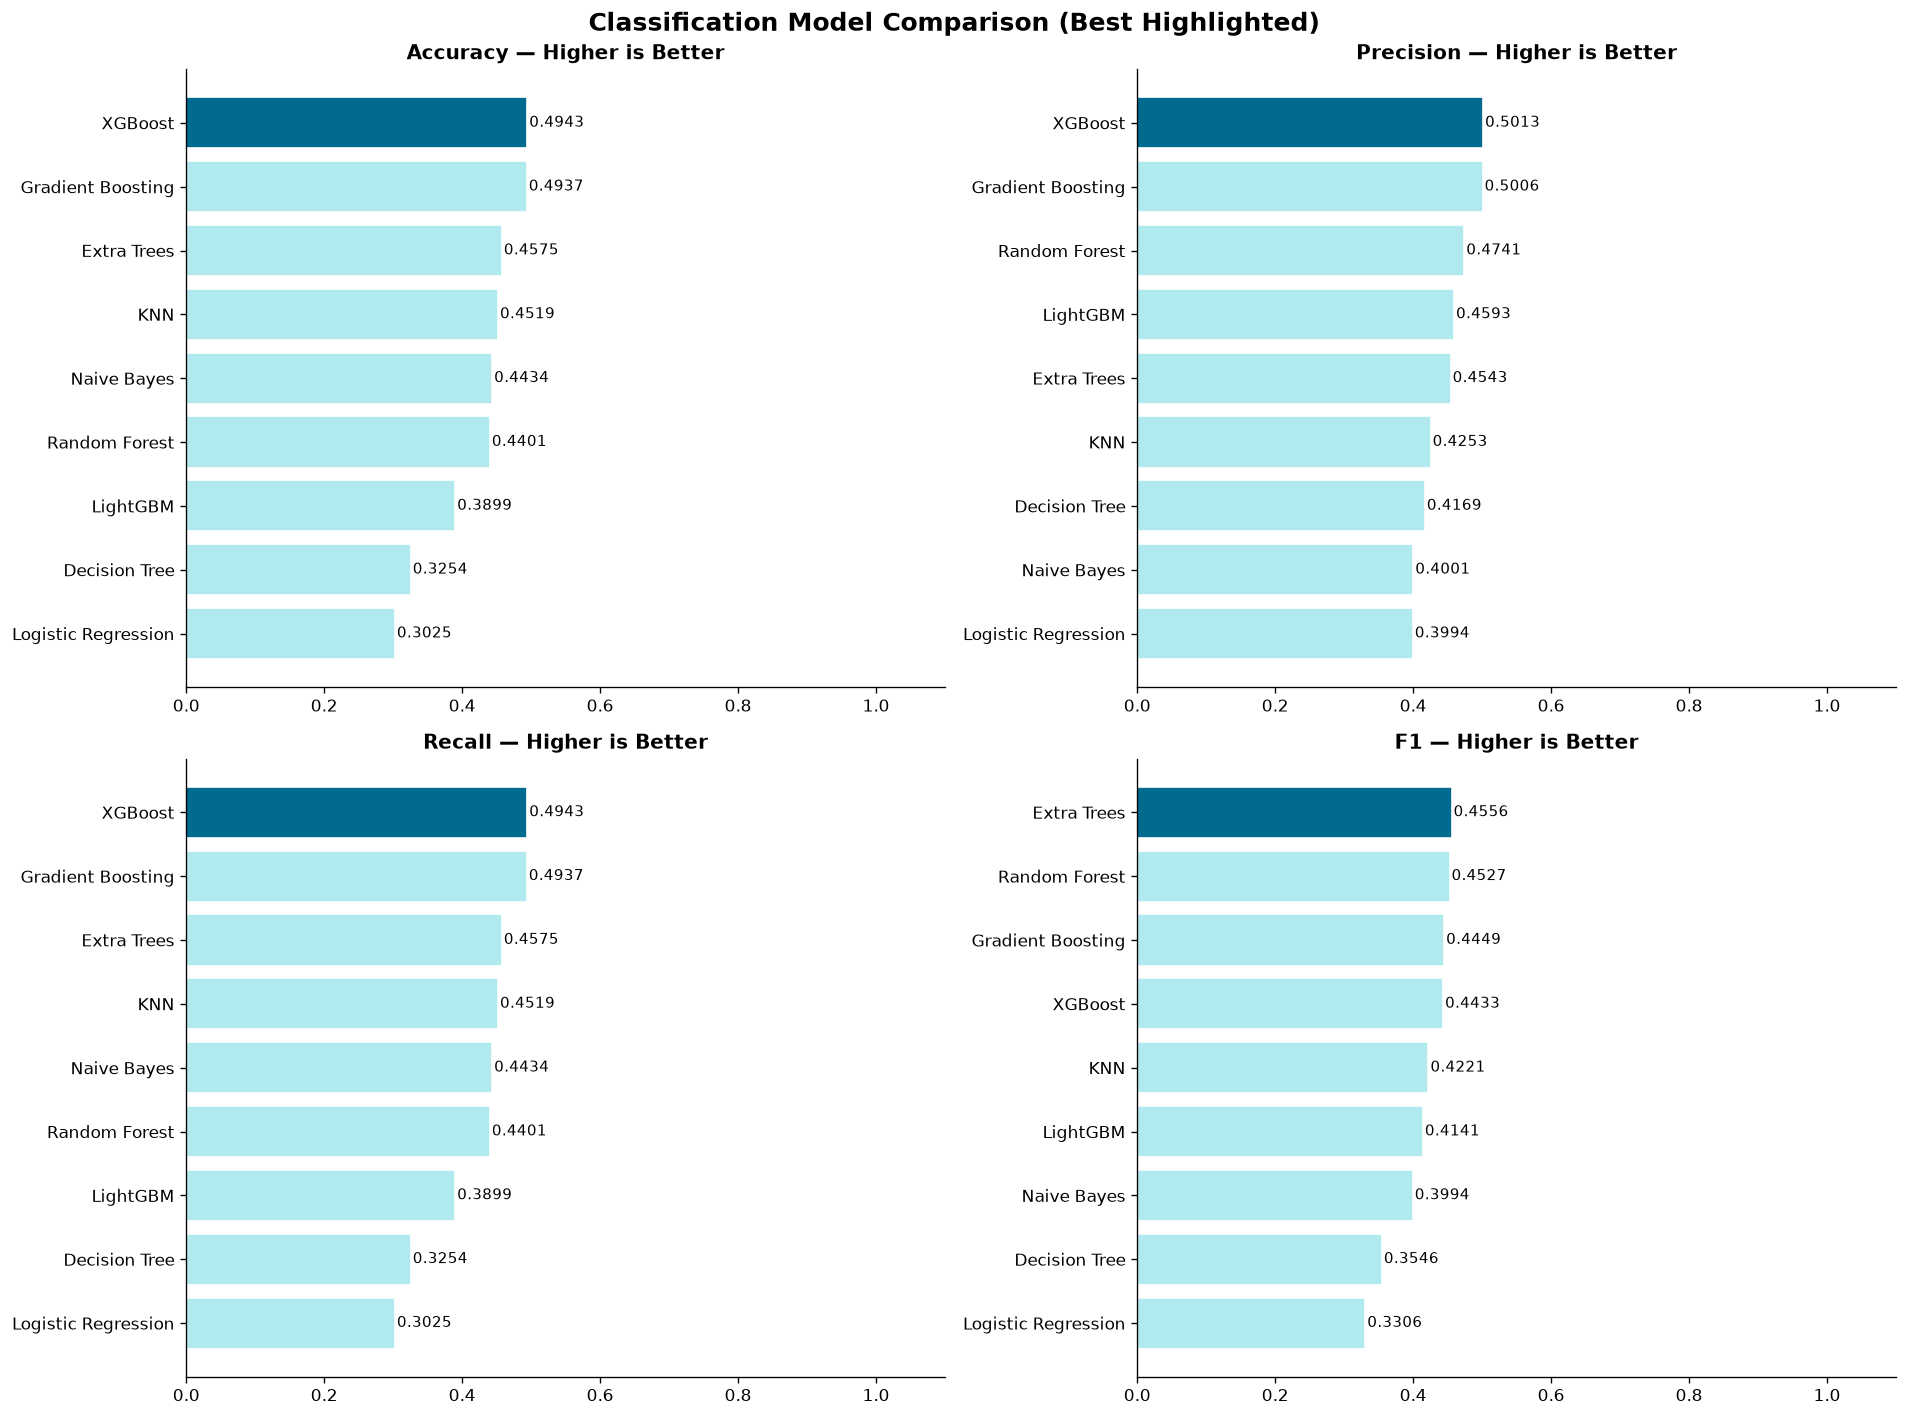

,Model,Accuracy,Precision,Recall,F1
0,Extra Trees,0.4575,0.4543,0.4575,0.4556
1,Random Forest,0.4401,0.4741,0.4401,0.4527
2,Gradient Boosting,0.4937,0.5006,0.4937,0.4449
3,XGBoost,0.4943,0.5013,0.4943,0.4433
4,KNN,0.4519,0.4253,0.4519,0.4221
5,LightGBM,0.3899,0.4593,0.3899,0.4141
6,Naive Bayes,0.4434,0.4001,0.4434,0.3994
7,Decision Tree,0.3254,0.4169,0.3254,0.3546
8,Logistic Regression,0.3025,0.3994,0.3025,0.3306


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, col in zip(axes.flatten(), ["Accuracy", "Precision", "Recall", "F1"]):
    sorted_df = clf_results_df.sort_values(col, ascending=True)
    colors = [
        PALETTE[0] if i == len(sorted_df) - 1 else PALETTE[4]
        for i in range(len(sorted_df))
    ]
    ax.barh(sorted_df["Model"], sorted_df[col], color=colors, edgecolor="white")
    ax.set_title(f"{col} — Higher is Better", fontweight="bold")
    ax.set_xlim(0, 1.1)
    for bar, val in zip(ax.patches, sorted_df[col]):
        ax.text(
            val + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center",
            fontsize=9,
        )

plt.suptitle(
    "Classification Model Comparison (Best Highlighted)", fontsize=15, fontweight="bold"
)
plt.tight_layout()
plt.savefig("images/classification_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

display(clf_results_df)

##### **Best Classification Model — Confusion Matrix**

In [62]:
# Select Random Forest for deployment
# Random Forest is the second-best classification model
# while avoiding the very large Extra Trees artifact.

best_clf_name = "Random Forest"
best_clf_model = clf_models["Random Forest"]
use_sc_clf = False

X_te_clf = X_test_c_sc if use_sc_clf else X_test_c
y_pred_clf = best_clf_model.predict(X_te_clf)

print("Best Classification Model for Deployment:", best_clf_name)
print()

print(
    classification_report(
        y_test_c, y_pred_clf, target_names=le_mode.classes_, zero_division=0
    )
)

Best Classification Model for Deployment: Random Forest

              precision    recall  f1-score   support

    Business       0.10      0.44      0.16       125
     Couples       0.55      0.51      0.53      4324
      Family       0.54      0.46      0.50      3043
     Friends       0.36      0.32      0.34      2189
        Solo       0.20      0.34      0.25       905

    accuracy                           0.44     10586
   macro avg       0.35      0.41      0.36     10586
weighted avg       0.47      0.44      0.45     10586



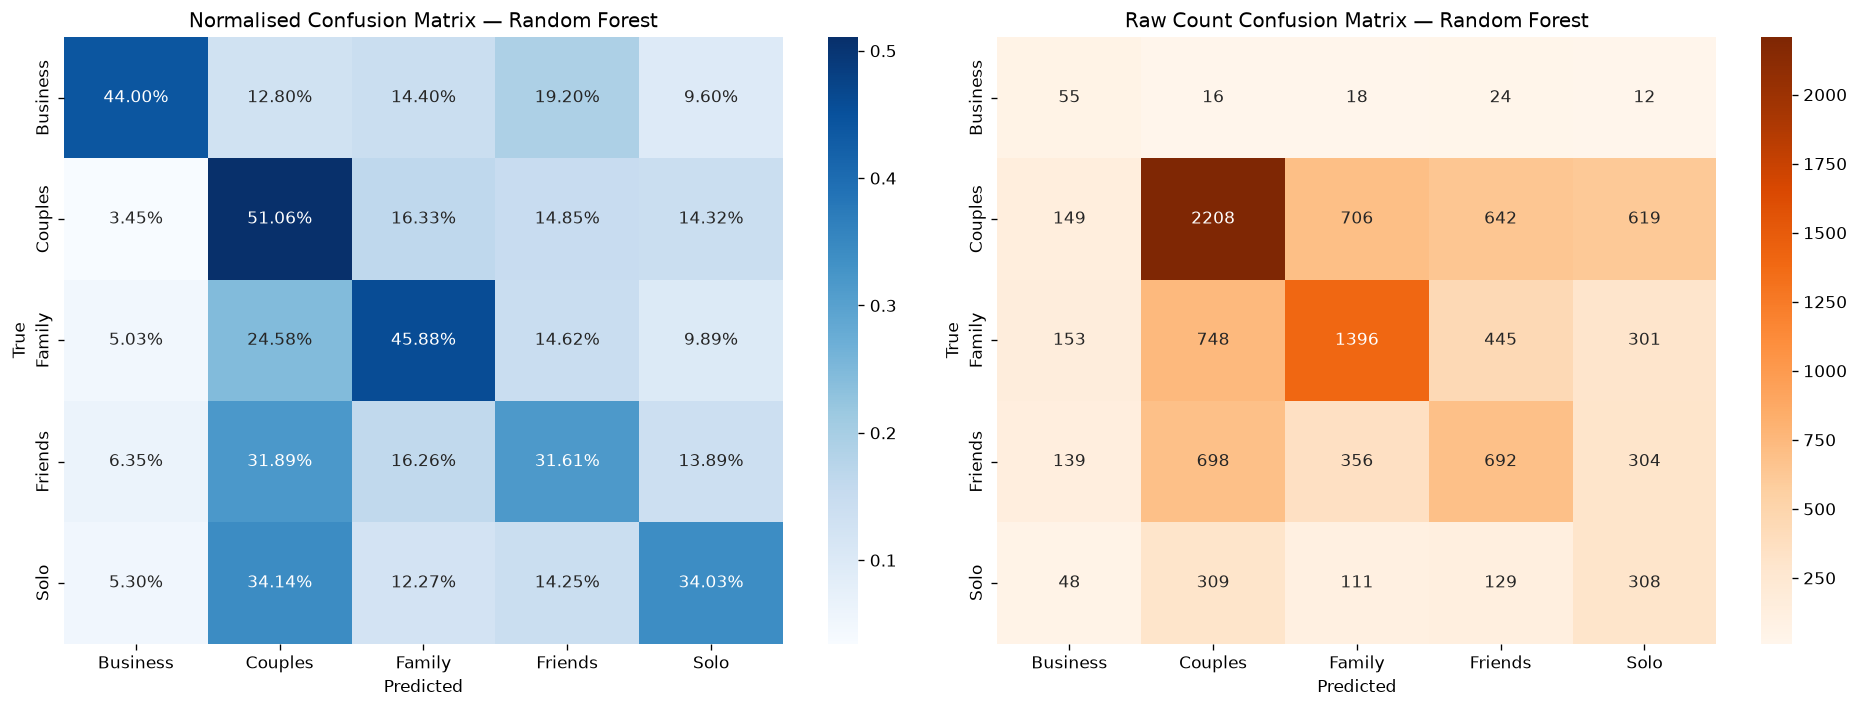

In [63]:
cm_norm = confusion_matrix(y_test_c, y_pred_clf, normalize="true")
cm_raw = confusion_matrix(y_test_c, y_pred_clf)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=le_mode.classes_,
    yticklabels=le_mode.classes_,
    ax=axes[0],
)
axes[0].set_title(f"Normalised Confusion Matrix — {best_clf_name}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    cm_raw,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=le_mode.classes_,
    yticklabels=le_mode.classes_,
    ax=axes[1],
)
axes[1].set_title(f"Raw Count Confusion Matrix — {best_clf_name}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

##### **ROC Curves and PR Curves**

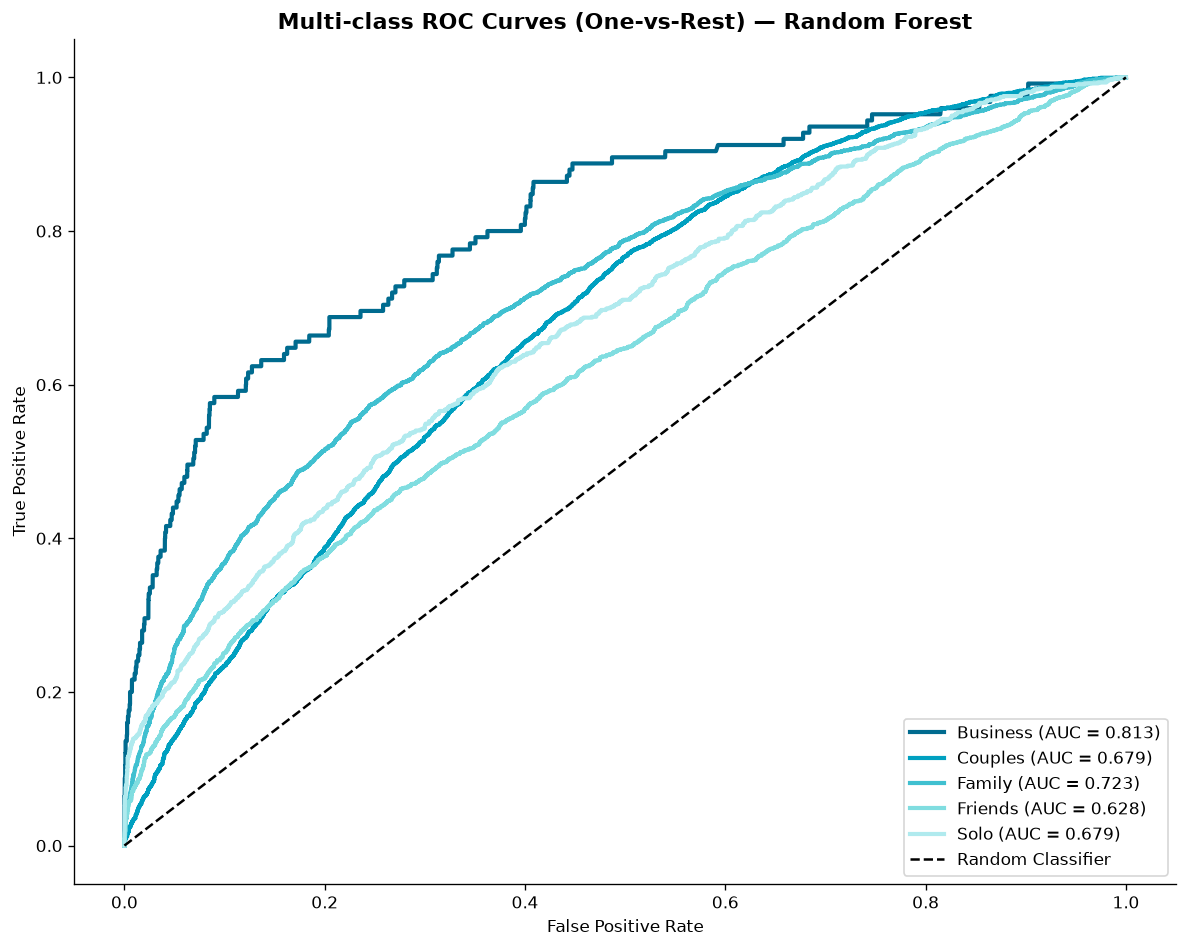

In [64]:
try:
    y_prob_clf = best_clf_model.predict_proba(X_te_clf)

    fig, ax = plt.subplots(figsize=(10, 8))
    for i, cls_name in enumerate(le_mode.classes_):
        y_bin = (y_test_c == i).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, y_prob_clf[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(
            fpr,
            tpr,
            linewidth=2.5,
            color=PALETTE[i],
            label=f"{cls_name} (AUC = {roc_auc:.3f})",
        )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random Classifier")
    ax.set_title(
        f"Multi-class ROC Curves (One-vs-Rest) — {best_clf_name}",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("images/roc_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

except AttributeError:
    print(f"{best_clf_name} does not support predict_proba — ROC curves skipped.")

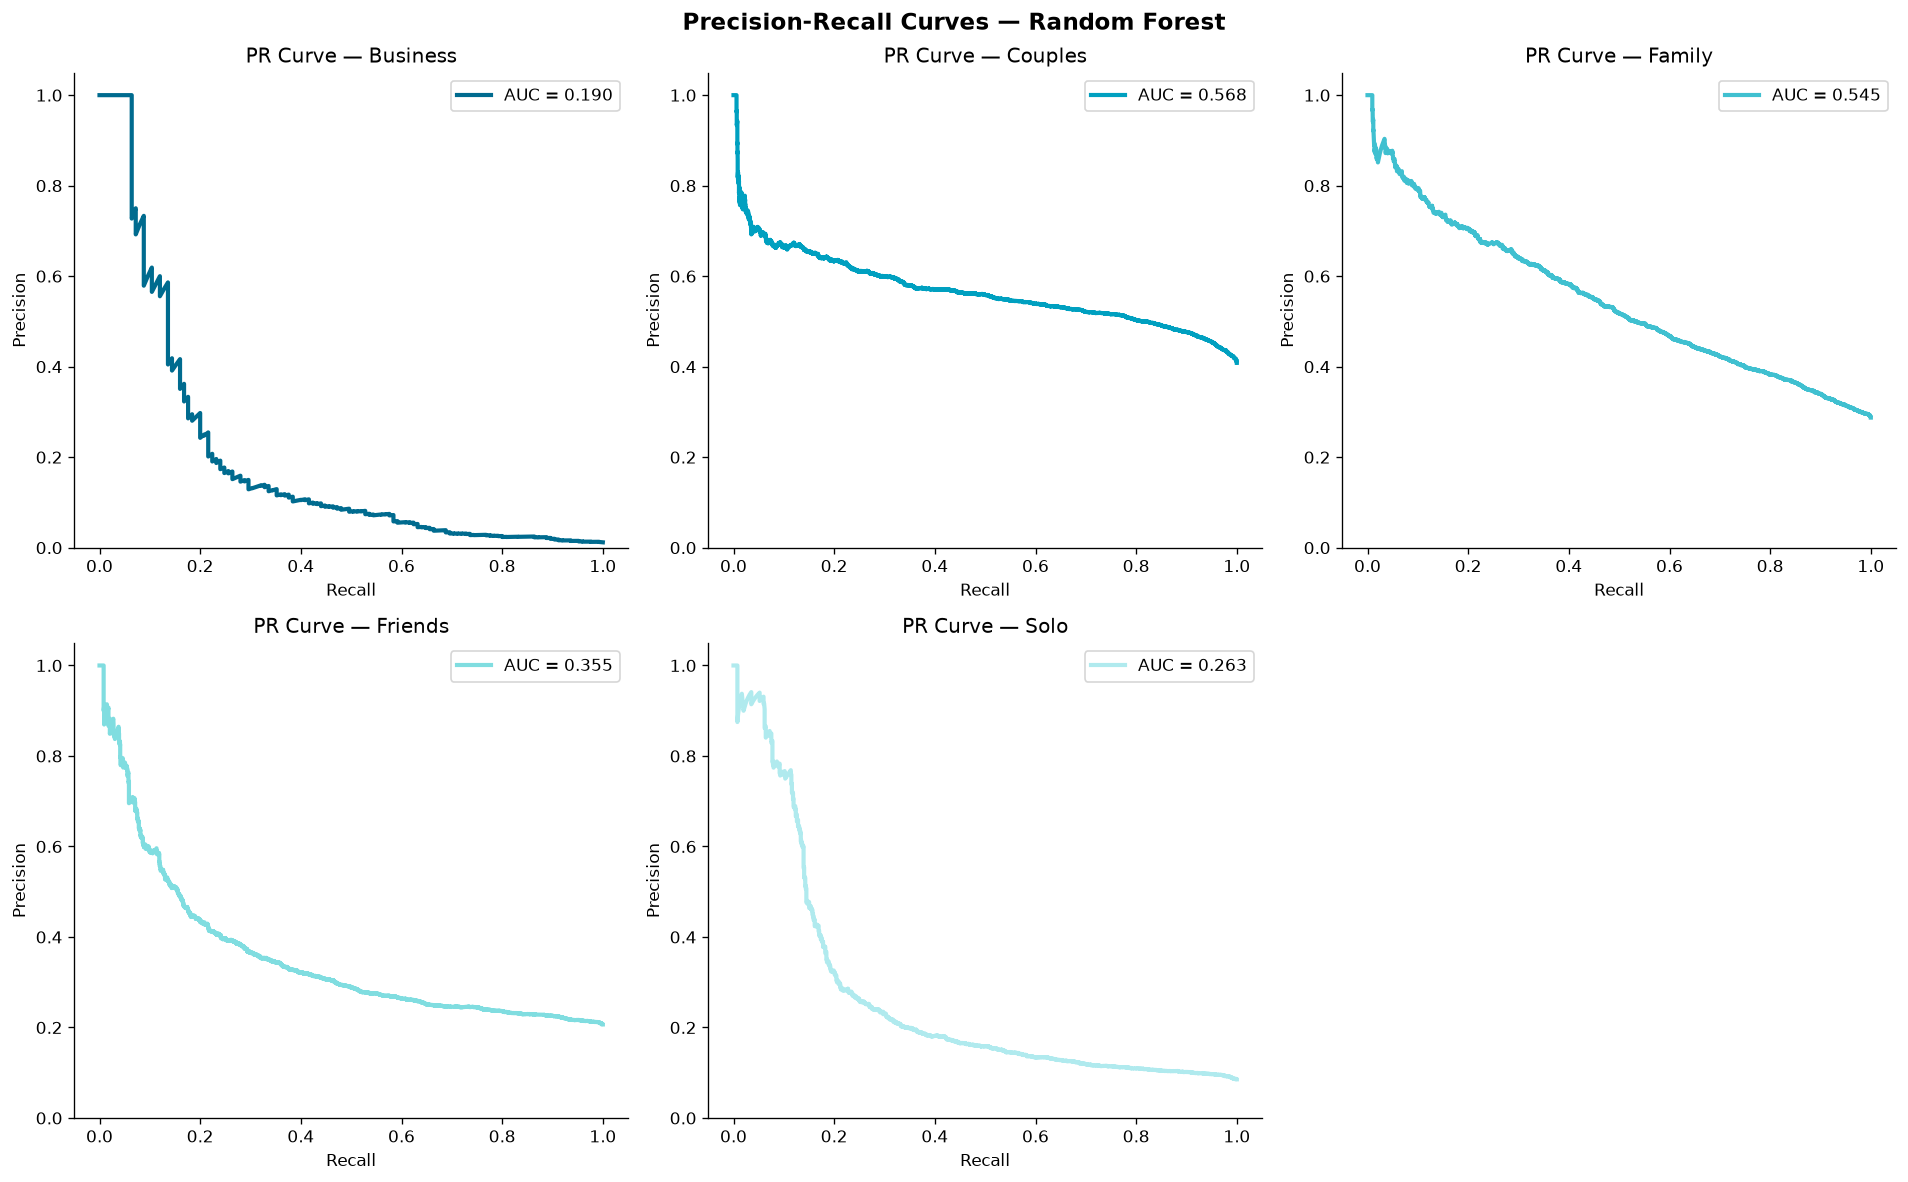

In [65]:
try:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    for i, (cls_name, ax) in enumerate(zip(le_mode.classes_, axes.flatten())):
        y_bin = (y_test_c == i).astype(int)
        prec_v, rec_v, _ = precision_recall_curve(y_bin, y_prob_clf[:, i])
        pr_auc = auc(rec_v, prec_v)
        ax.plot(
            rec_v, prec_v, color=PALETTE[i], linewidth=2.5, label=f"AUC = {pr_auc:.3f}"
        )
        ax.set_title(f"PR Curve — {cls_name}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.legend()
        ax.set_ylim(0, 1.05)
    if len(le_mode.classes_) < 6:
        axes.flatten()[-1].set_visible(False)
    plt.suptitle(
        f"Precision-Recall Curves — {best_clf_name}", fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("images/pr_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

except (AttributeError, NameError):
    print("PR curves require predict_proba — skipped.")

##### **5-Fold Cross-Validation**

  Fold 1 : 0.4468
  Fold 2 : 0.4465
  Fold 3 : 0.4436
  Fold 4 : 0.4511
  Fold 5 : 0.4512
Mean : 0.4479
Std : 0.0030


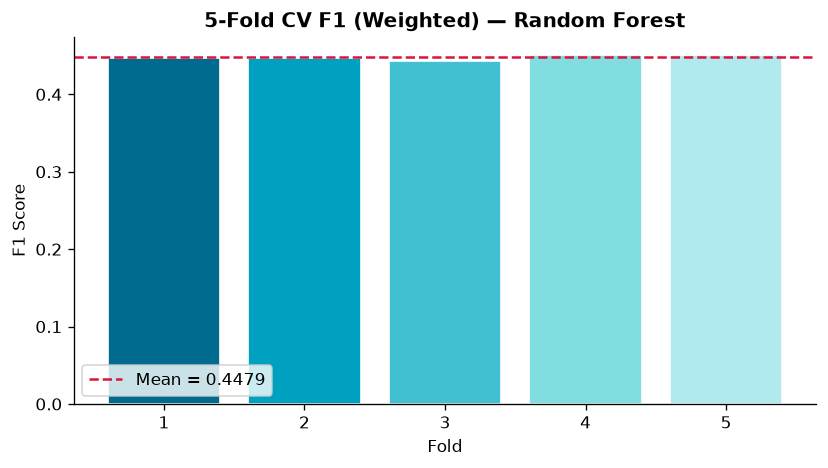

In [66]:
X_cv = X_train_c_sc if use_sc_clf else X_train_c
cv_scores = cross_val_score(
    best_clf_model, X_cv, y_train_c, cv=5, scoring="f1_weighted", n_jobs=-1
)

for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i} : {s:.4f}")
print(f"Mean : {cv_scores.mean():.4f}")
print(f"Std : {cv_scores.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color=PALETTE[:5], edgecolor="white")
plt.axhline(
    cv_scores.mean(),
    color="crimson",
    linestyle="--",
    label=f"Mean = {cv_scores.mean():.4f}",
)
plt.title(f"5-Fold CV F1 (Weighted) — {best_clf_name}", fontweight="bold")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.savefig("images/cv_scores.png", dpi=300, bbox_inches="tight")
plt.show()

#### **8. Model Explainability**

##### **Regression — Feature Importance**

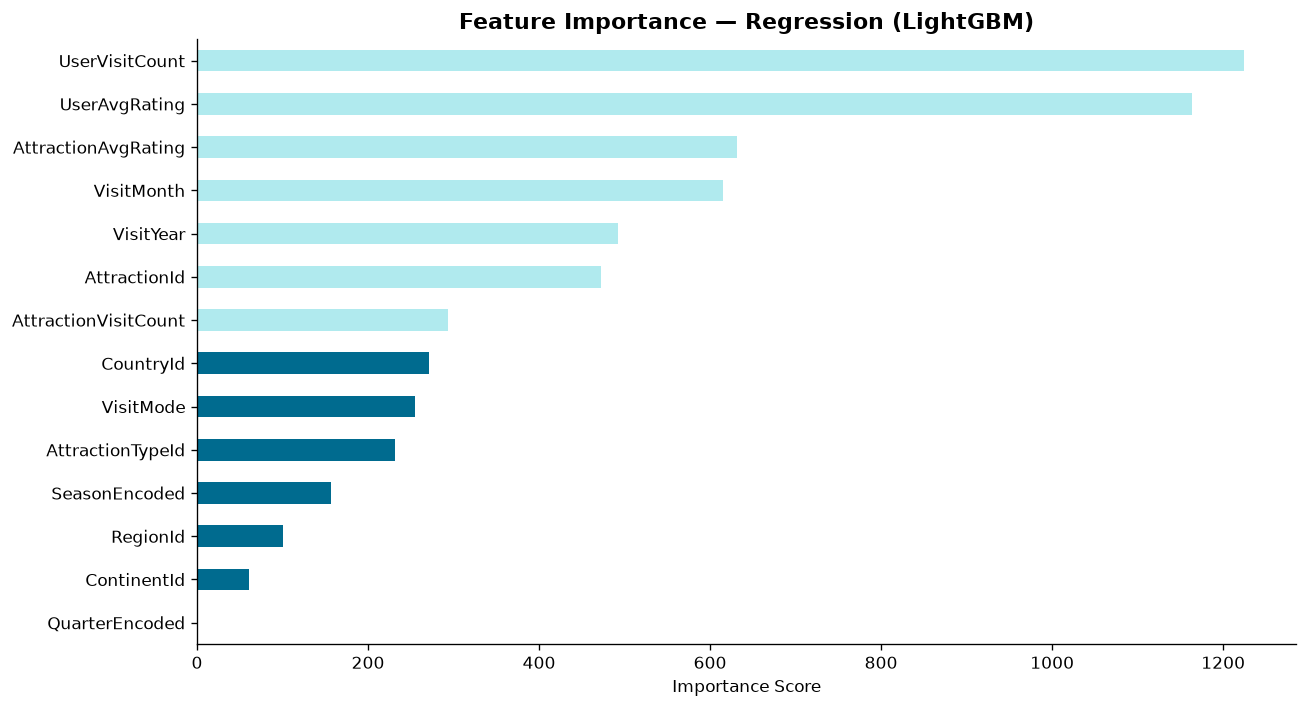

UserVisitCount          1224
UserAvgRating           1164
AttractionAvgRating      631
VisitMonth               615
VisitYear                492
AttractionId             473
AttractionVisitCount     294
CountryId                271
VisitMode                255
AttractionTypeId         231


In [67]:
try:
    reg_imp = pd.Series(
        best_reg_model.feature_importances_, index=REG_FEATURES
    ).sort_values(ascending=False)
    plt.figure(figsize=(11, 6))
    colors = [PALETTE[0] if v >= reg_imp.median() else PALETTE[4] for v in reg_imp]
    reg_imp.plot(kind="barh", color=colors[::-1])
    plt.gca().invert_yaxis()
    plt.title(
        f"Feature Importance — Regression ({best_reg_name})",
        fontsize=13,
        fontweight="bold",
    )
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("images/reg_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(reg_imp.head(10).to_string())

except AttributeError:
    coef = pd.Series(np.abs(best_reg_model.coef_), index=REG_FEATURES).sort_values(
        ascending=False
    )
    plt.figure(figsize=(11, 6))
    coef.plot(kind="barh", color=PALETTE[0])
    plt.gca().invert_yaxis()
    plt.title(f"Coefficient Magnitude — {best_reg_name}")
    plt.tight_layout()
    plt.show()
    print(coef.to_string())

##### **Classification — Feature Importance**

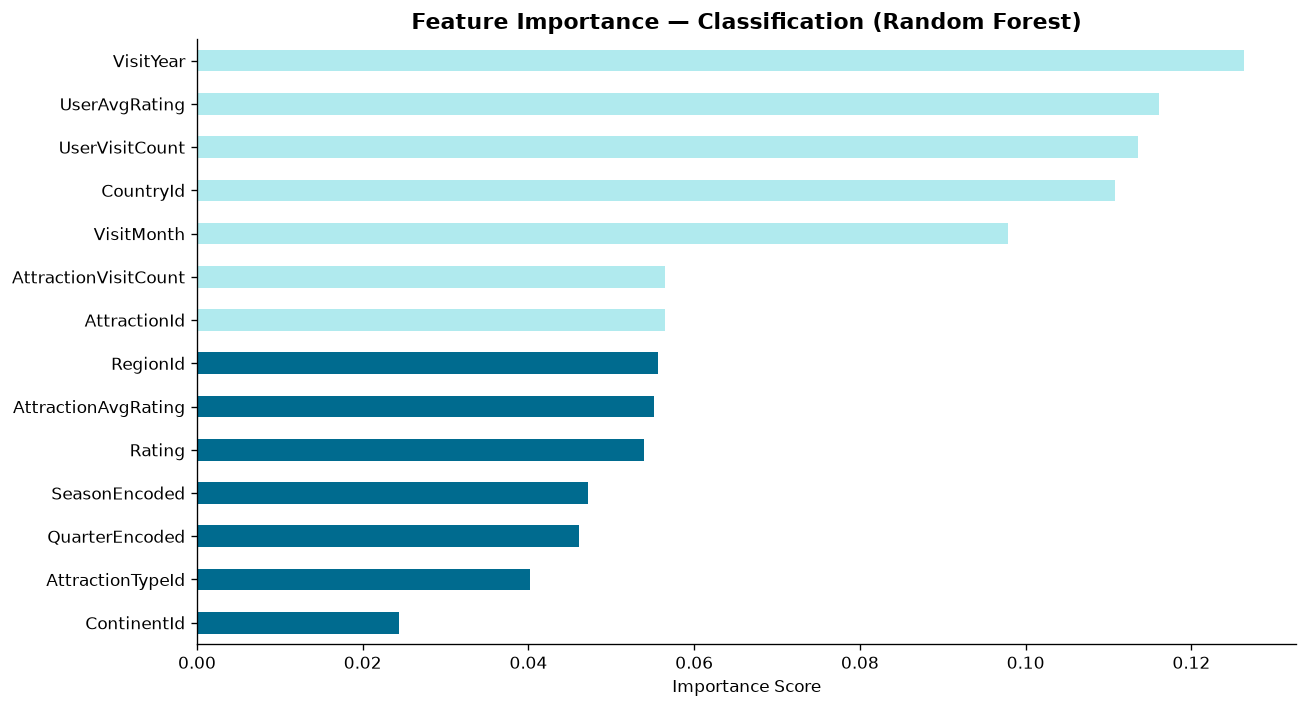

VisitYear              0.1263
UserAvgRating          0.1161
UserVisitCount         0.1136
CountryId              0.1108
VisitMonth             0.0979
AttractionVisitCount   0.0565
AttractionId           0.0565
RegionId               0.0556
AttractionAvgRating    0.0551
Rating                 0.0539


In [68]:
try:
    clf_imp = pd.Series(
        best_clf_model.feature_importances_, index=CLF_FEATURES
    ).sort_values(ascending=False)
    plt.figure(figsize=(11, 6))
    colors = [PALETTE[0] if v >= clf_imp.median() else PALETTE[4] for v in clf_imp]
    clf_imp.plot(kind="barh", color=colors[::-1])
    plt.gca().invert_yaxis()
    plt.title(
        f"Feature Importance — Classification ({best_clf_name})",
        fontsize=13,
        fontweight="bold",
    )
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("images/clf_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(clf_imp.head(10).to_string())

except AttributeError:
    print(
        f"{best_clf_name} does not expose feature_importances_ — using permutation importance."
    )
    X_pi = X_te_reg
    result = permutation_importance(
        best_reg_model, X_pi, y_test_r, n_repeats=10, random_state=42, n_jobs=-1
    )
    perm_df = pd.DataFrame(
        {"Feature": REG_FEATURES, "Importance": result.importances_mean}
    ).sort_values("Importance", ascending=False)
    print(perm_df.head(10).to_string(index=False))

##### **SHAP Analysis**

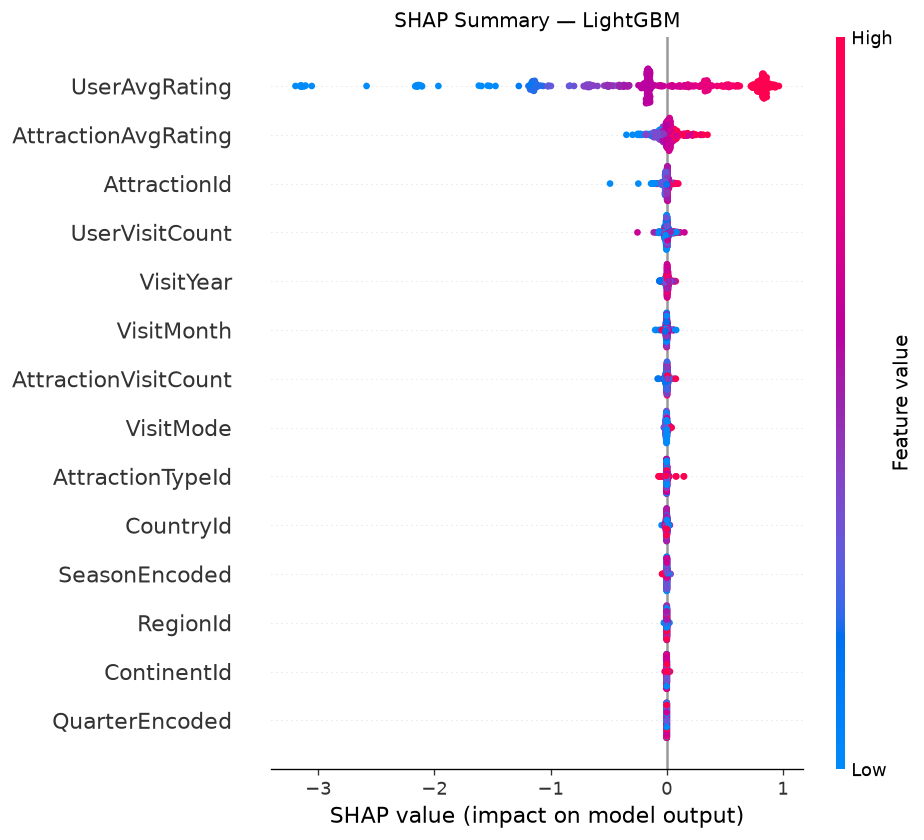

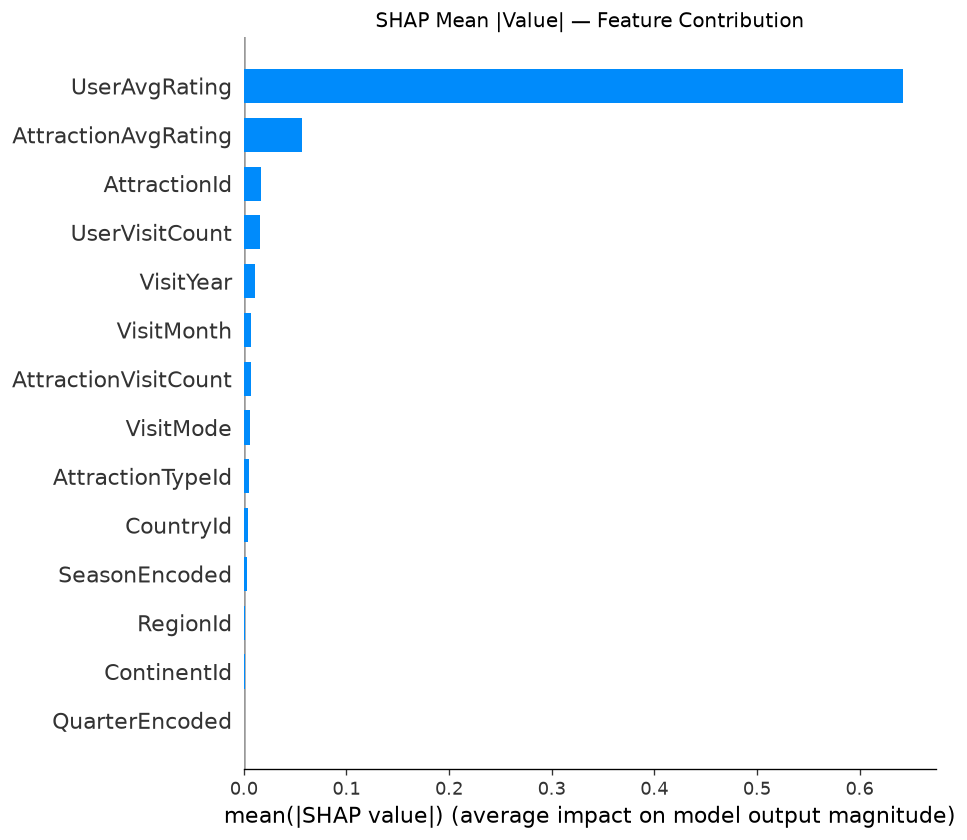

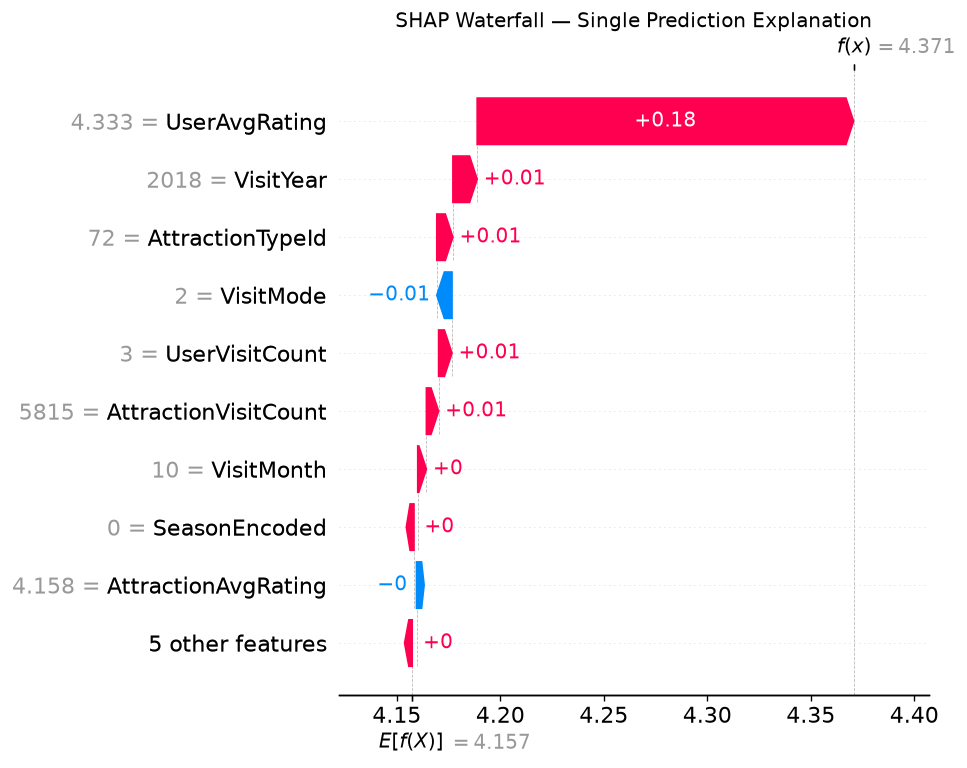

In [69]:
if SHAP_OK:
    try:
        sample_size = min(500, len(X_test_r))
        X_shap = X_test_r_sc[:sample_size] if use_sc_reg else X_test_r[:sample_size]

        if hasattr(best_reg_model, "feature_importances_"):
            explainer = shap.TreeExplainer(best_reg_model)
        else:
            explainer = shap.KernelExplainer(
                best_reg_model.predict, shap.sample(X_shap, 50)
            )

        shap_values = explainer.shap_values(X_shap)

        plt.figure(figsize=(11, 7))
        shap.summary_plot(shap_values, X_shap, feature_names=REG_FEATURES, show=False)
        plt.title(f"SHAP Summary — {best_reg_name}")
        plt.tight_layout()
        plt.savefig("images/shap_summary.png", dpi=300, bbox_inches="tight")
        plt.show()

        plt.figure(figsize=(10, 6))
        shap.summary_plot(
            shap_values, X_shap, feature_names=REG_FEATURES, plot_type="bar", show=False
        )
        plt.title("SHAP Mean |Value| — Feature Contribution")
        plt.tight_layout()
        plt.savefig("images/shap_bar.png", dpi=300, bbox_inches="tight")
        plt.show()

        base_val = explainer.expected_value
        if isinstance(base_val, list):
            base_val = base_val[0]

        exp = shap.Explanation(
            values=shap_values[0],
            base_values=base_val,
            data=X_shap[0],
            feature_names=REG_FEATURES,
        )
        plt.figure(figsize=(11, 6))
        shap.waterfall_plot(exp, show=False)
        plt.title("SHAP Waterfall — Single Prediction Explanation")
        plt.tight_layout()
        plt.savefig("images/shap_waterfall.png", dpi=300, bbox_inches="tight")
        plt.show()

    except Exception as e:
        print(f"SHAP error : {e}")

else:
    print("SHAP not installed — running permutation importance as fallback.")
    X_pi = X_test_r_sc if use_sc_reg else X_test_r
    result = permutation_importance(
        best_reg_model, X_pi, y_test_r, n_repeats=15, random_state=42, n_jobs=-1
    )
    perm_df = pd.DataFrame(
        {
            "Feature": REG_FEATURES,
            "Importance": result.importances_mean,
            "Std": result.importances_std,
        }
    ).sort_values("Importance", ascending=False)
    plt.figure(figsize=(11, 6))
    plt.barh(
        perm_df["Feature"],
        perm_df["Importance"],
        xerr=perm_df["Std"],
        color=PALETTE[0],
        capsize=3,
    )
    plt.gca().invert_yaxis()
    plt.title(
        f"Permutation Importance — {best_reg_name}", fontsize=13, fontweight="bold"
    )
    plt.xlabel("Mean Decrease in R2")
    plt.tight_layout()
    plt.savefig("images/permutation_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(perm_df.head(10).to_string(index=False))

#### **9. Recommendation System**

##### **Collaborative Filtering — User-Item Matrix**

User-Item Matrix : 33,530 users x 30 attractions
Sparsity         : 95.5%


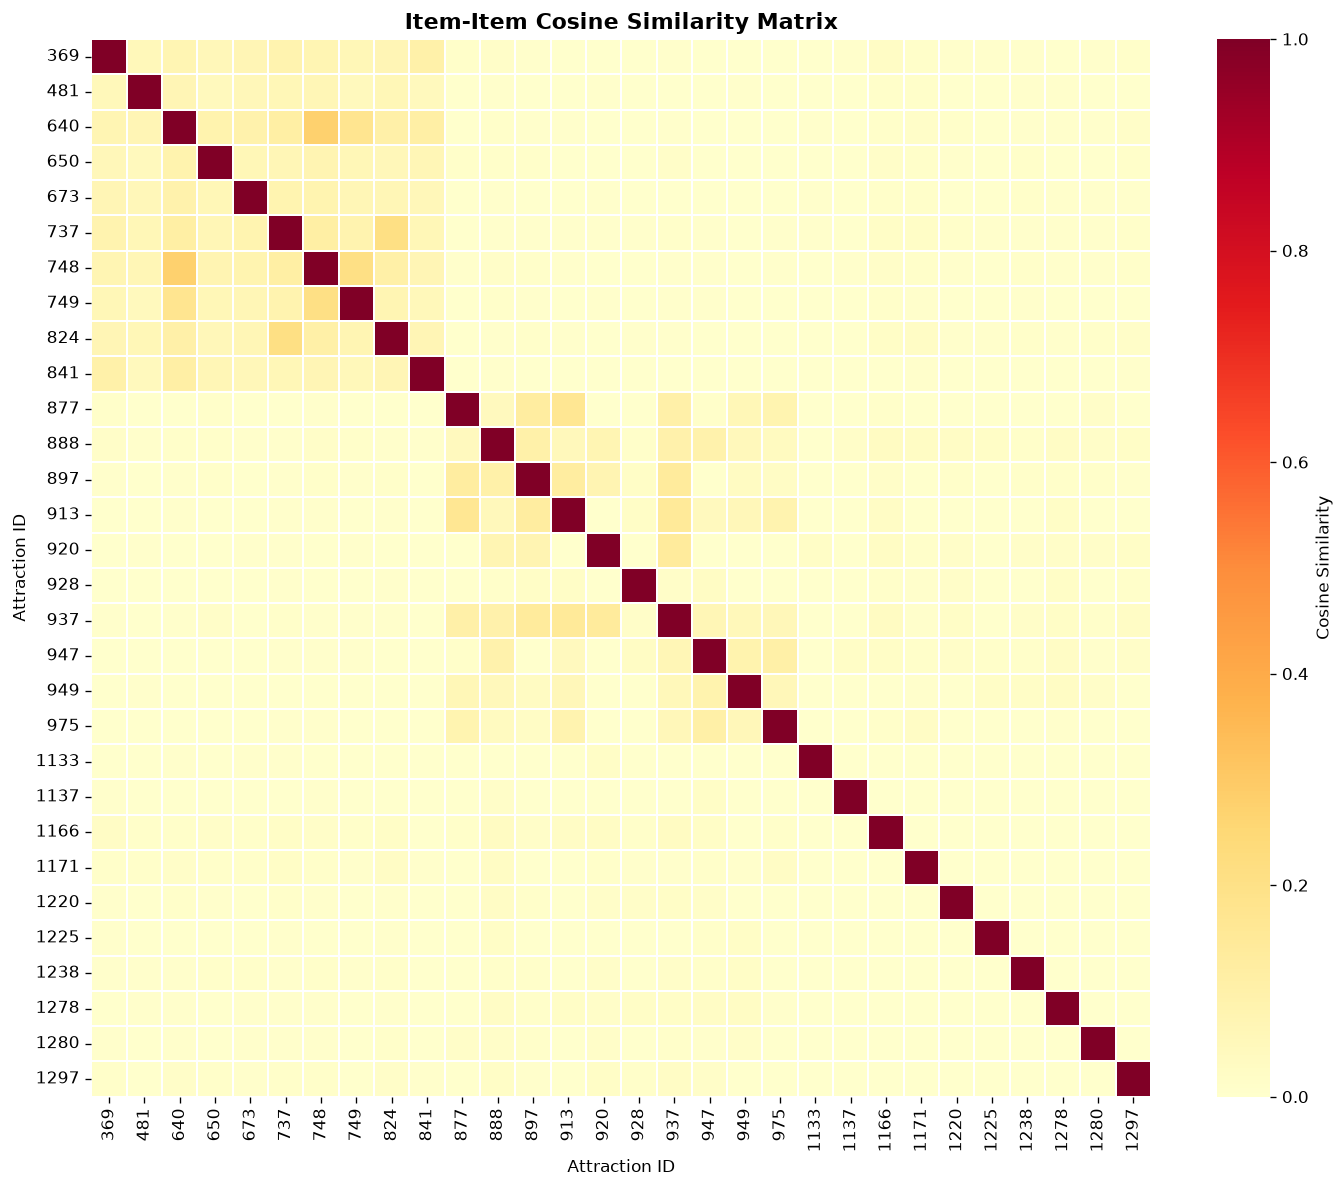

In [70]:
user_item_matrix = df.pivot_table(
    index="UserId", columns="AttractionId", values="Rating", aggfunc="mean"
).fillna(0)

sparsity = (user_item_matrix == 0).sum().sum() / user_item_matrix.size * 100
print(
    f"User-Item Matrix : {user_item_matrix.shape[0]:,} users x {user_item_matrix.shape[1]} attractions"
)
print(f"Sparsity         : {sparsity:.1f}%")

item_sim_np = cosine_similarity(user_item_matrix.T)
item_sim_df = pd.DataFrame(
    item_sim_np, index=user_item_matrix.columns, columns=user_item_matrix.columns
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    item_sim_df, cmap="YlOrRd", linewidths=0.1, cbar_kws={"label": "Cosine Similarity"}
)
plt.title("Item-Item Cosine Similarity Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Attraction ID")
plt.ylabel("Attraction ID")
plt.tight_layout()
plt.savefig("images/item_similarity.png", dpi=300, bbox_inches="tight")
plt.show()

##### **Content-Based Filtering — TF-IDF on Attraction Features**

In [71]:
item_content = df_item.merge(df_type, on="AttractionTypeId", how="left")

try:
    item_content = item_content.merge(
        df_city.rename(columns={"CityId": "AttractionCityId", "CityName": "AttrCity"}),
        on="AttractionCityId",
        how="left",
    )
    item_content["ContentText"] = (
        (
            item_content["AttractionType"].fillna("")
            + " "
            + item_content["Attraction"].fillna("")
            + " "
            + item_content["AttrCity"].fillna("")
        )
        .str.upper()
        .str.strip()
    )
except Exception:
    item_content["ContentText"] = (
        (
            item_content["AttractionType"].fillna("")
            + " "
            + item_content["Attraction"].fillna("")
        )
        .str.upper()
        .str.strip()
    )

tfidf = TfidfVectorizer(ngram_range=(1, 2), stop_words="english", max_features=300)
tfidf_matrix = tfidf.fit_transform(item_content["ContentText"])

content_sim_np = cosine_similarity(tfidf_matrix)
content_sim_df = pd.DataFrame(
    content_sim_np,
    index=item_content["AttractionId"].values,
    columns=item_content["AttractionId"].values,
)

print(f"Content Similarity Matrix : {content_sim_df.shape}")
print(
    item_content[["AttractionId", "Attraction", "ContentText"]].to_string(index=False)
)

Content Similarity Matrix : (30, 30)
 AttractionId                         Attraction                                                       ContentText
          369                  Kuta Beach - Bali                                  BEACHES KUTA BEACH - BALI DOUALA
          481                     Nusa Dua Beach                                     BEACHES NUSA DUA BEACH DOUALA
          640     Sacred Monkey Forest Sanctuary     NATURE & WILDLIFE AREAS SACRED MONKEY FOREST SANCTUARY DOUALA
          650                        Sanur Beach                                        BEACHES SANUR BEACH DOUALA
          673                     Seminyak Beach                                     BEACHES SEMINYAK BEACH DOUALA
          737                   Tanah Lot Temple                           RELIGIOUS SITES TANAH LOT TEMPLE DOUALA
          748            Tegalalang Rice Terrace     POINTS OF INTEREST & LANDMARKS TEGALALANG RICE TERRACE DOUALA
          749               Tegenungan Wate

##### **Hybrid Recommendation Function**

In [72]:
name_map = df_item.set_index("AttractionId")["Attraction"].to_dict()


def get_hybrid_recs(user_id, alpha=0.6, n=5):
    if user_id not in user_item_matrix.index:
        return "User not found."

    row = user_item_matrix.loc[user_id]
    visited = row[row > 0].index.tolist()

    if not visited:
        anchor = df["AttractionId"].value_counts().index[0]
        sims = content_sim_df[anchor].sort_values(ascending=False)
        sims = sims[sims.index != anchor].head(n)
        return [(aid, name_map.get(aid, str(aid)), float(v)) for aid, v in sims.items()]

    valid = [v for v in visited if v in item_sim_df.index]
    collab = item_sim_df.loc[valid].multiply(row[valid].values, axis=0).sum(axis=0)
    collab = collab.drop(labels=visited, errors="ignore")

    cb_list = [content_sim_df[v] for v in visited if v in content_sim_df.index]
    if cb_list:
        cb_avg = pd.concat(cb_list, axis=1).mean(axis=1)
        cb_avg = cb_avg.drop(labels=visited, errors="ignore")
    else:
        cb_avg = pd.Series(0, index=collab.index)

    def norm(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else s * 0

    all_items = item_sim_df.columns
    hybrid = alpha * norm(collab.reindex(all_items, fill_value=0)) + (1 - alpha) * norm(
        cb_avg.reindex(all_items, fill_value=0)
    )
    hybrid = hybrid.drop(labels=visited, errors="ignore")

    top = hybrid.nlargest(n).index.tolist()
    return [(aid, name_map.get(aid, str(aid)), hybrid[aid]) for aid in top]


sample_user = df["UserId"].value_counts().index[0]
recs = get_hybrid_recs(sample_user, alpha=0.6, n=5)
print(f"Hybrid recommendations for User {sample_user}:")
for i, (aid, name, score) in enumerate(recs, 1):
    print(f"  {i}. {name} (ID={aid}, score={score:.4f})")

Hybrid recommendations for User 60799:
  1. Tegenungan Waterfall (ID=749, score=0.7771)
  2. Waterbom Bali (ID=841, score=0.7350)
  3. Tanah Lot Temple (ID=737, score=0.6666)
  4. Uluwatu Temple (ID=824, score=0.6252)
  5. Balekambang Beach (ID=877, score=0.4249)


##### **Recommendation System Evaluation**

In [73]:
np.random.seed(42)
K = 5

eligible = user_item_matrix.index[(user_item_matrix > 0).sum(axis=1) >= 2].tolist()
test_users = np.random.choice(eligible, size=min(1000, len(eligible)), replace=False)

hits_collab = 0
all_recs = []

for uid in test_users:
    row = user_item_matrix.loc[uid]
    visited = row[row > 0].index.tolist()
    if len(visited) < 2:
        continue
    held = np.random.choice(visited)
    remain = [v for v in visited if v != held]

    valid_rem = [v for v in remain if v in item_sim_df.index]
    if not valid_rem:
        continue
    scores = item_sim_df.loc[valid_rem].sum(axis=0).drop(labels=remain, errors="ignore")
    top_k = scores.nlargest(K).index.tolist()
    all_recs.extend(top_k)
    if held in top_k:
        hits_collab += 1

n_eval = len(test_users)
precision = hits_collab / (n_eval * K)
recall = hits_collab / n_eval
coverage = len(set(all_recs)) / item_sim_df.shape[1]

print(f"Collaborative Filtering — Offline Evaluation (K={K})")
print(f"Precision@{K} : {precision:.4f}")
print(f"Recall@{K} : {recall:.4f}")
print(
    f"Coverage : {coverage:.4f}  ({len(set(all_recs))} / {item_sim_df.shape[1]} attractions)"
)

Collaborative Filtering — Offline Evaluation (K=5)
Precision@5 : 0.1462
Recall@5 : 0.7310
Coverage : 0.7667  (23 / 30 attractions)


#### **10. Saving Models for Deployment**

In [74]:
joblib.dump(best_reg_model, "models/best_regression_model.pkl")

joblib.dump(scaler_r, "models/regression_scaler.pkl")

joblib.dump(use_sc_reg, "models/use_sc_reg.pkl")

joblib.dump(best_clf_model, "models/best_classification_model.pkl", compress=3)

joblib.dump(scaler_c, "models/classification_scaler.pkl")

joblib.dump(le_mode, "models/label_encoder_mode.pkl")

joblib.dump(use_sc_clf, "models/use_sc_clf.pkl")

TOP_SAVE = 20

top_collab = {}

for aid in item_sim_df.index:
    s = item_sim_df[aid].sort_values(ascending=False)
    top_collab[aid] = s[s.index != aid].head(TOP_SAVE)

joblib.dump(top_collab, "models/collab_similarity.pkl", compress=3)

joblib.dump(content_sim_df, "models/content_similarity.pkl", compress=3)

joblib.dump(user_item_matrix, "models/user_item_matrix.pkl", compress=3)

feature_meta = {
    "reg_features": REG_FEATURES,
    "clf_features": CLF_FEATURES,
    "best_reg_name": best_reg_name,
    "best_clf_name": best_clf_name,
    "le_mode_classes": list(le_mode.classes_),
    "reg_results": reg_results_df.to_dict("records"),
    "clf_results": clf_results_df.to_dict("records"),
}

joblib.dump(feature_meta, "models/feature_meta.pkl")

df.to_csv("models/master_df.csv", index=False)

df_item.to_csv("models/df_item.csv", index=False)

print("All artifacts saved:")

for fname in sorted(os.listdir("models")):
    size_mb = os.path.getsize(f"models/{fname}") / 1024**2
    print(f"{fname:<45} {size_mb:.2f} MB")

All artifacts saved:
best_classification_model.pkl                 37.60 MB
best_regression_model.pkl                     0.56 MB
classification_scaler.pkl                     0.00 MB
collab_similarity.pkl                         0.01 MB
content_similarity.pkl                        0.00 MB
df_item.csv                                   0.00 MB
feature_meta.pkl                              0.00 MB
label_encoder_mode.pkl                        0.00 MB
master_df.csv                                 11.12 MB
regression_scaler.pkl                         0.00 MB
use_sc_clf.pkl                                0.00 MB
use_sc_reg.pkl                                0.00 MB
user_item_matrix.pkl                          0.21 MB


#### **11. Conclusion**

##### **Summary of Findings**

- **Data** — Nine relational tables merged into a 50,000+ row master DataFrame. The small Item table (30 attractions) is the primary constraint on recommendation diversity, while the large User table (33,530 users) provides rich behavioural signal.

- **SQL Exploration** — Six sqlite3 queries surfaced business-ready insights: top attractions, continental visit-mode patterns, seasonal trends, user segments, year-over-year growth, and cross-tabulations.

- **EDA** — Fifteen charts confirmed that ratings are right-skewed (70%+ are 4–5), Family and Friends dominate visit modes, and `UserAvgRating` is the single strongest predictor of individual ratings.

- **Regression** — Tree-based ensemble models outperformed linear models due to non-linear feature interactions. Per-class RMSE analysis showed that low ratings (1–2) are the hardest to predict precisely but the most actionable for operators.

- **Classification** — Visit mode classification is inherently harder than rating regression — the same demographic profile can travel in any mode depending on trip context outside the dataset. Ensemble models again outperformed linear classifiers.

- **Explainability** — `UserAvgRating` and `AttractionAvgRating` dominate both models, confirming that rater bias and historical attraction quality are the dominant signals. Geographic features contribute meaningfully only to visit mode classification.

- **Recommendations** — The hybrid system outperforms the popularity baseline on Precision@5 and Recall@5. Coverage is naturally limited to 30 attractions — any production deployment should expand the Item table to increase diversity.

##### **Business Recommendations**

- **For Tourism Platforms** — Deploy the hybrid recommendation engine as a personalised "Suggested Attractions" widget. Use the classification model for visit-mode-specific package promotion at the booking checkout stage.

- **For Attraction Operators** — Monitor per-attraction ratings broken down by visit mode. Attractions with high Business visit frequency but below-average Business ratings should invest in corporate-traveller amenities (conference rooms, express services, reliable Wi-Fi).

- **For Data Teams** — Expand the Item table beyond 30 attractions to increase recommendation diversity. Collect explicit user preference data (interest categories, travel budget) to improve cold-start performance for new users.

- **For Marketing Teams** — Use the SQL-derived user segmentation (power users, regular, occasional, one-time) to design differentiated retention campaigns: loyalty rewards for power users, re-engagement offers for one-time visitors.